In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd

In [ ]:
maxout = 1000
flist = ["gb1_Ngbn11_L1_T900", "gb1_Ngbn21_L1_T900", "gb1_Ngbn31_L1_T900", "gb1_Ngbn41_L1_T900"]
Np = len(flist)
bdmax = np.zeros((Np, maxout))
btot = np.zeros((Np, maxout))
sim_time = np.zeros((Np, maxout))
nit = np.zeros(Np, dtype=int)
Ngb_list = np.zeros(Np, dtype=int)
for i, fname in enumerate(flist):
    gbdd = dd.GB_dislocations(from_file="../examples/gbdd/"+fname+".h5")
    print(f"Data file with N_gbn={gbddNgbn}, delta={gbdn.Dgp}, dtmax={gbdd.dtmax}")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    gbdd.plot_time_series('max_bdot')
    gbdd.plot_field('displacement')
    gbdd.plot_field('flux')
    nit[i] = gbdd.nout
    Ngb_list[i] = gbdd.Ngbn
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    bdmax[i, 0:gbdd.nout] = gbdd.glob_data['max_bdot']
    btot[i, 0:gbdd.nout] = gbdd.glob_data['n_gbdis_eff']

                          

Simulation with N_gbn=11, delta=0.01, dtmax=62.50000000000001
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        0.0000000000000000        1.0000000000000000       0.10000000000000001               11
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)      500000   62.500000000000000        15.470852067256077        4.6471419760400587E-013   2.7273558197248151E-004           0           1  -1.7976931348623157E+308
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)     1000000   62.500000000000000        46.720852067256075        3.0392047491031967E-013   1.9994976704037980E-004           0           1  -1.7976931348623157E+308
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)     1500000   62.500000000000000        77.970852067256075        2.2262010098917937E-013   1.4643493305442086E-004           0           1  -1.7976931348623157E+308
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)     20000

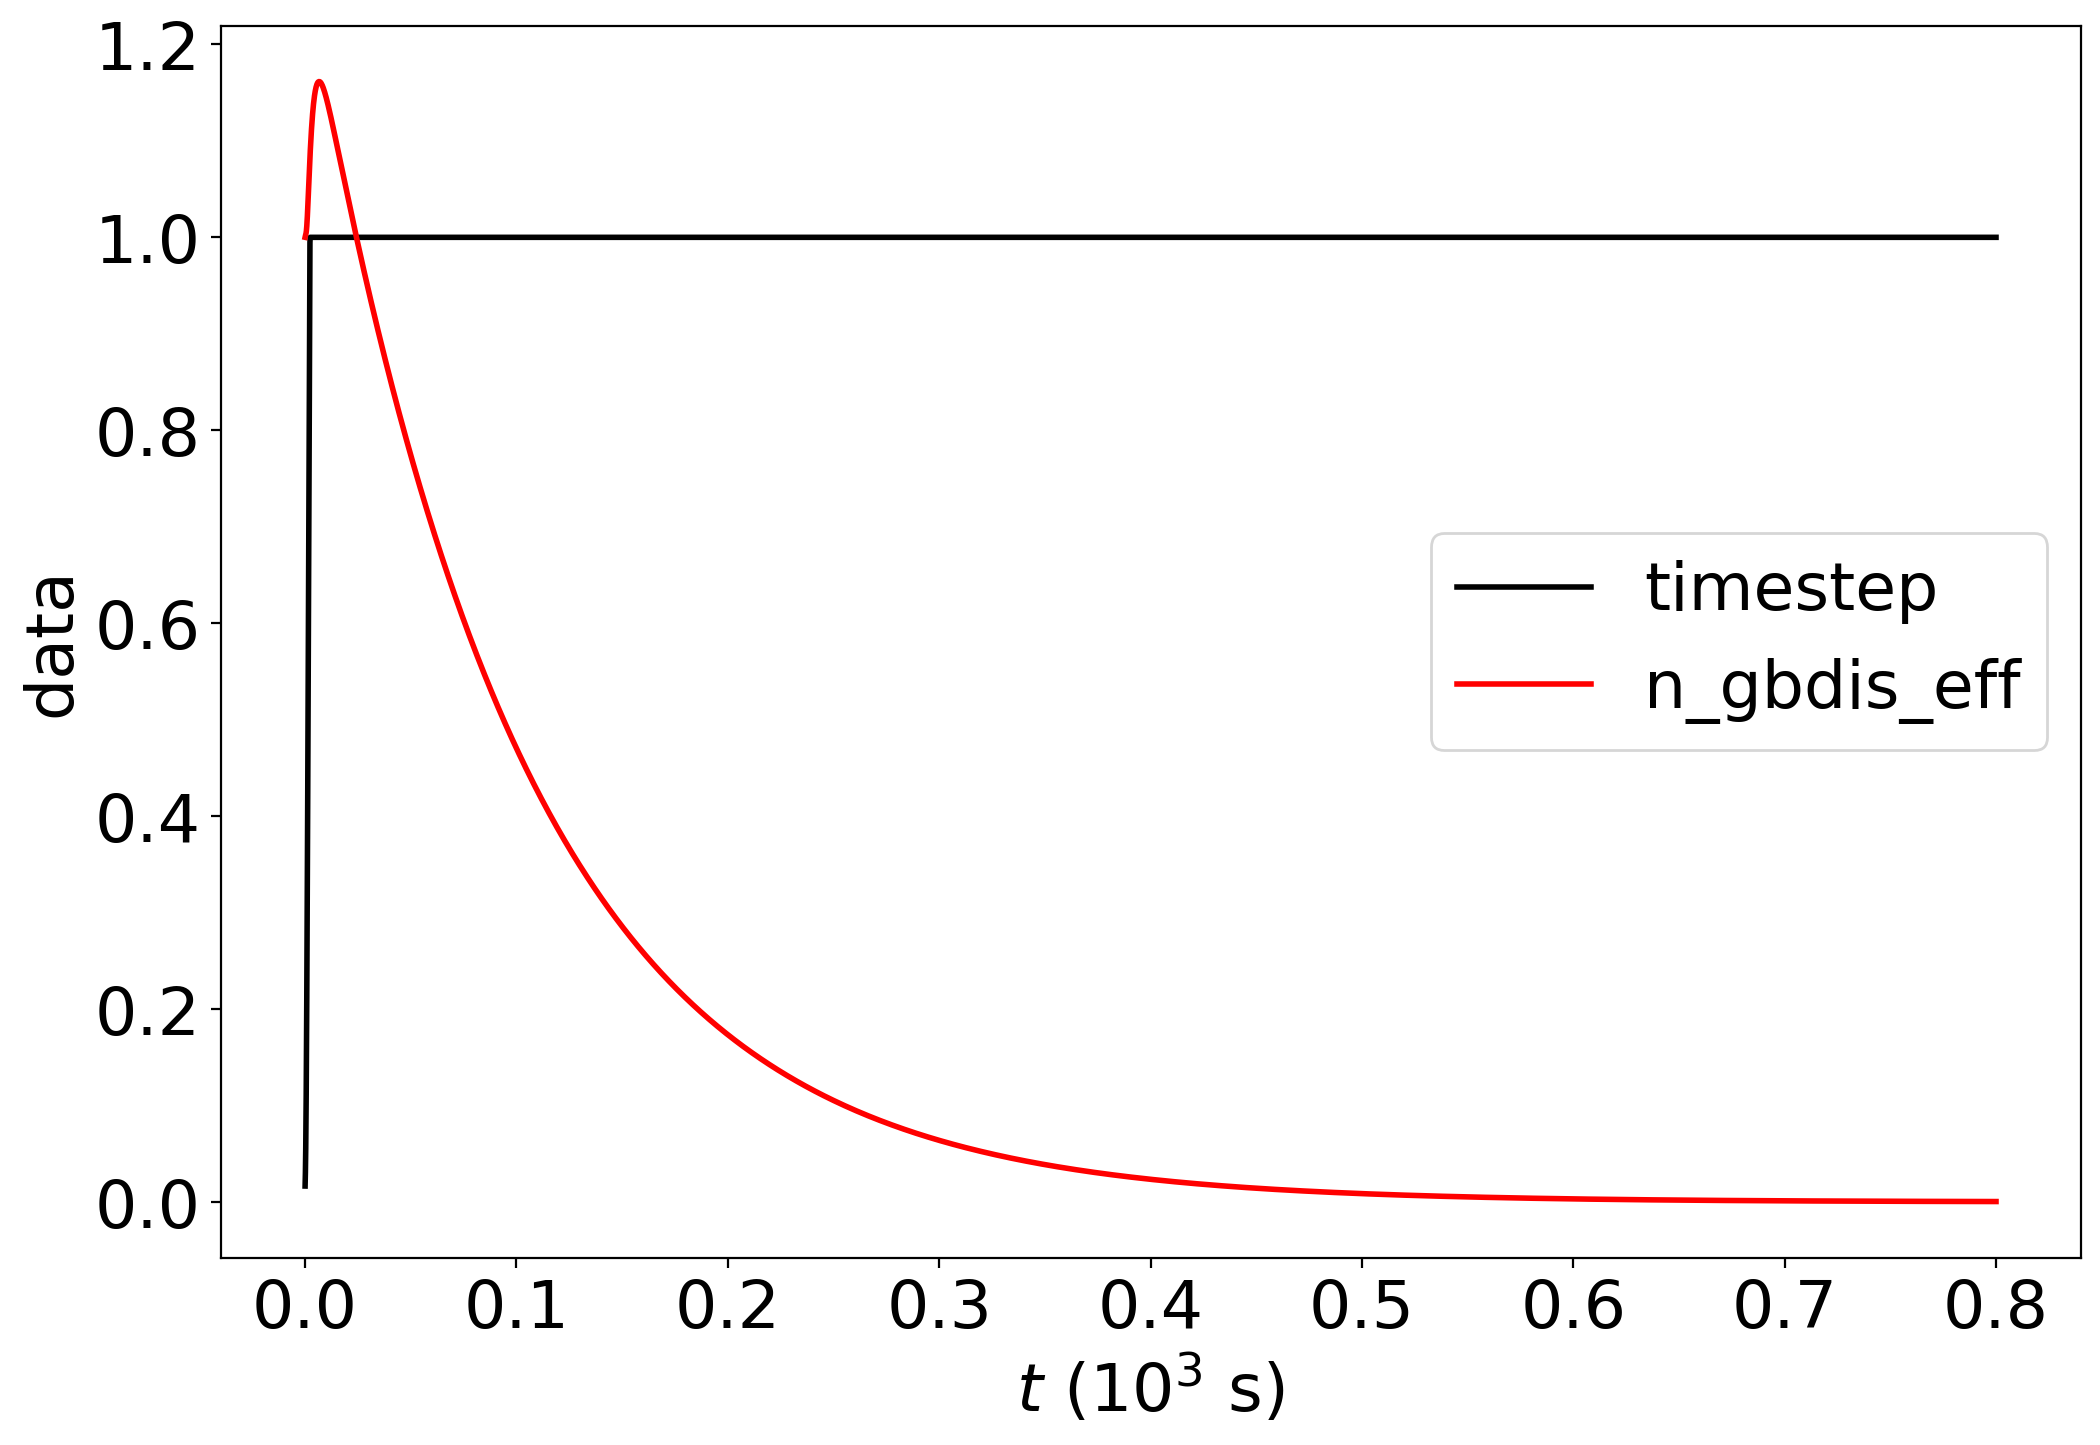

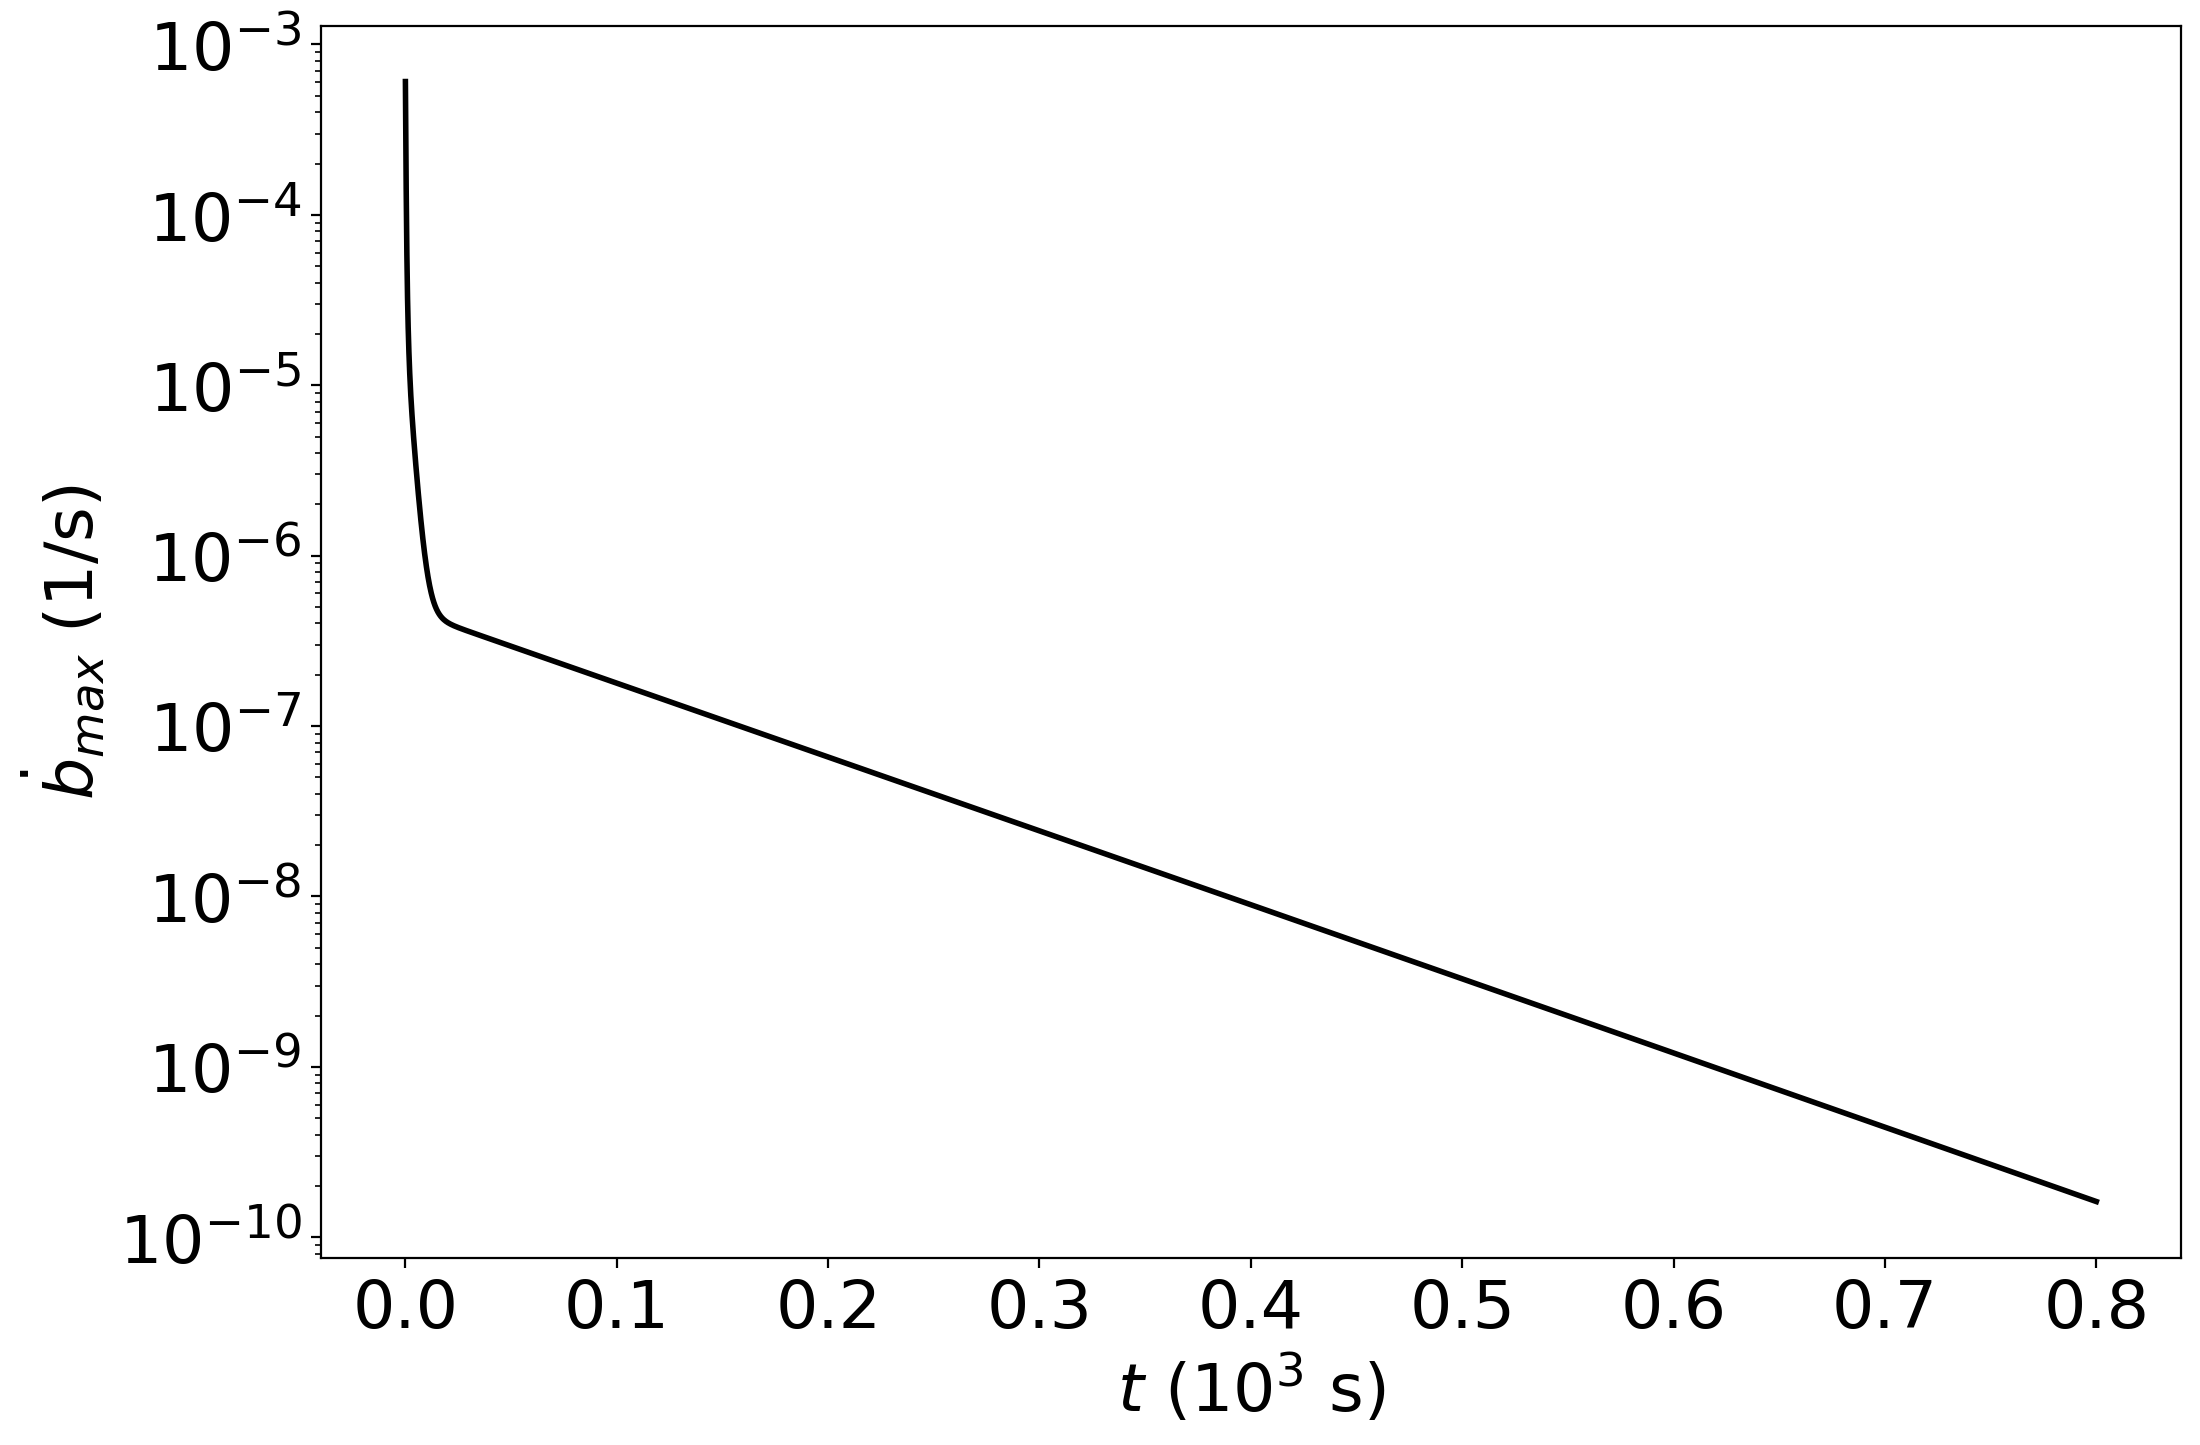

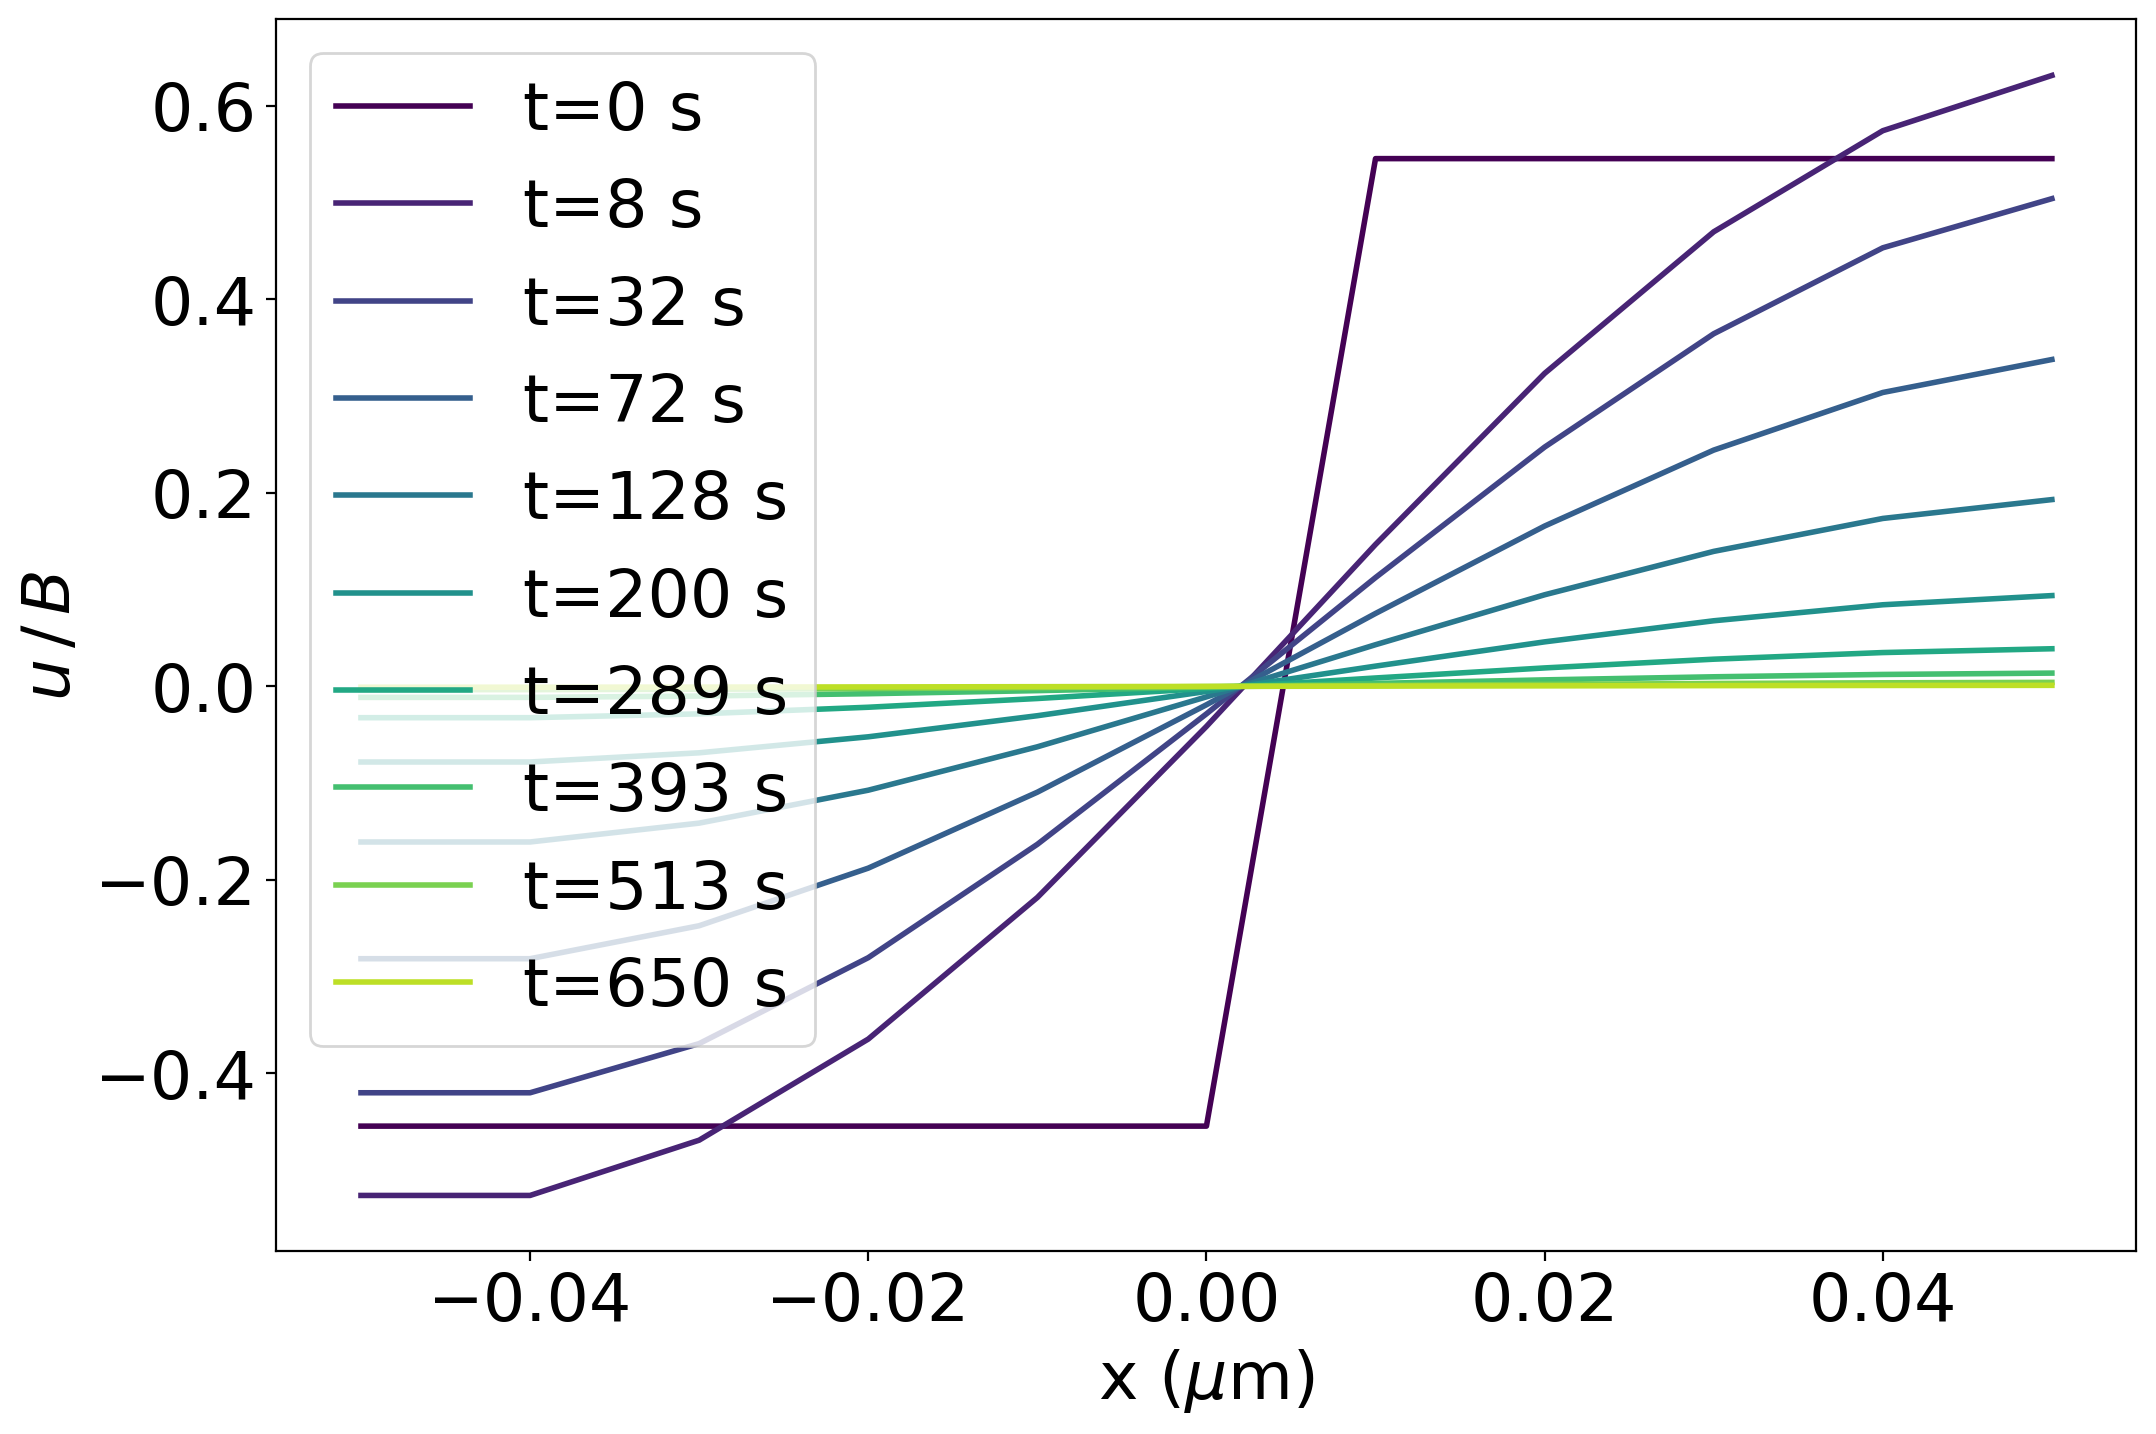

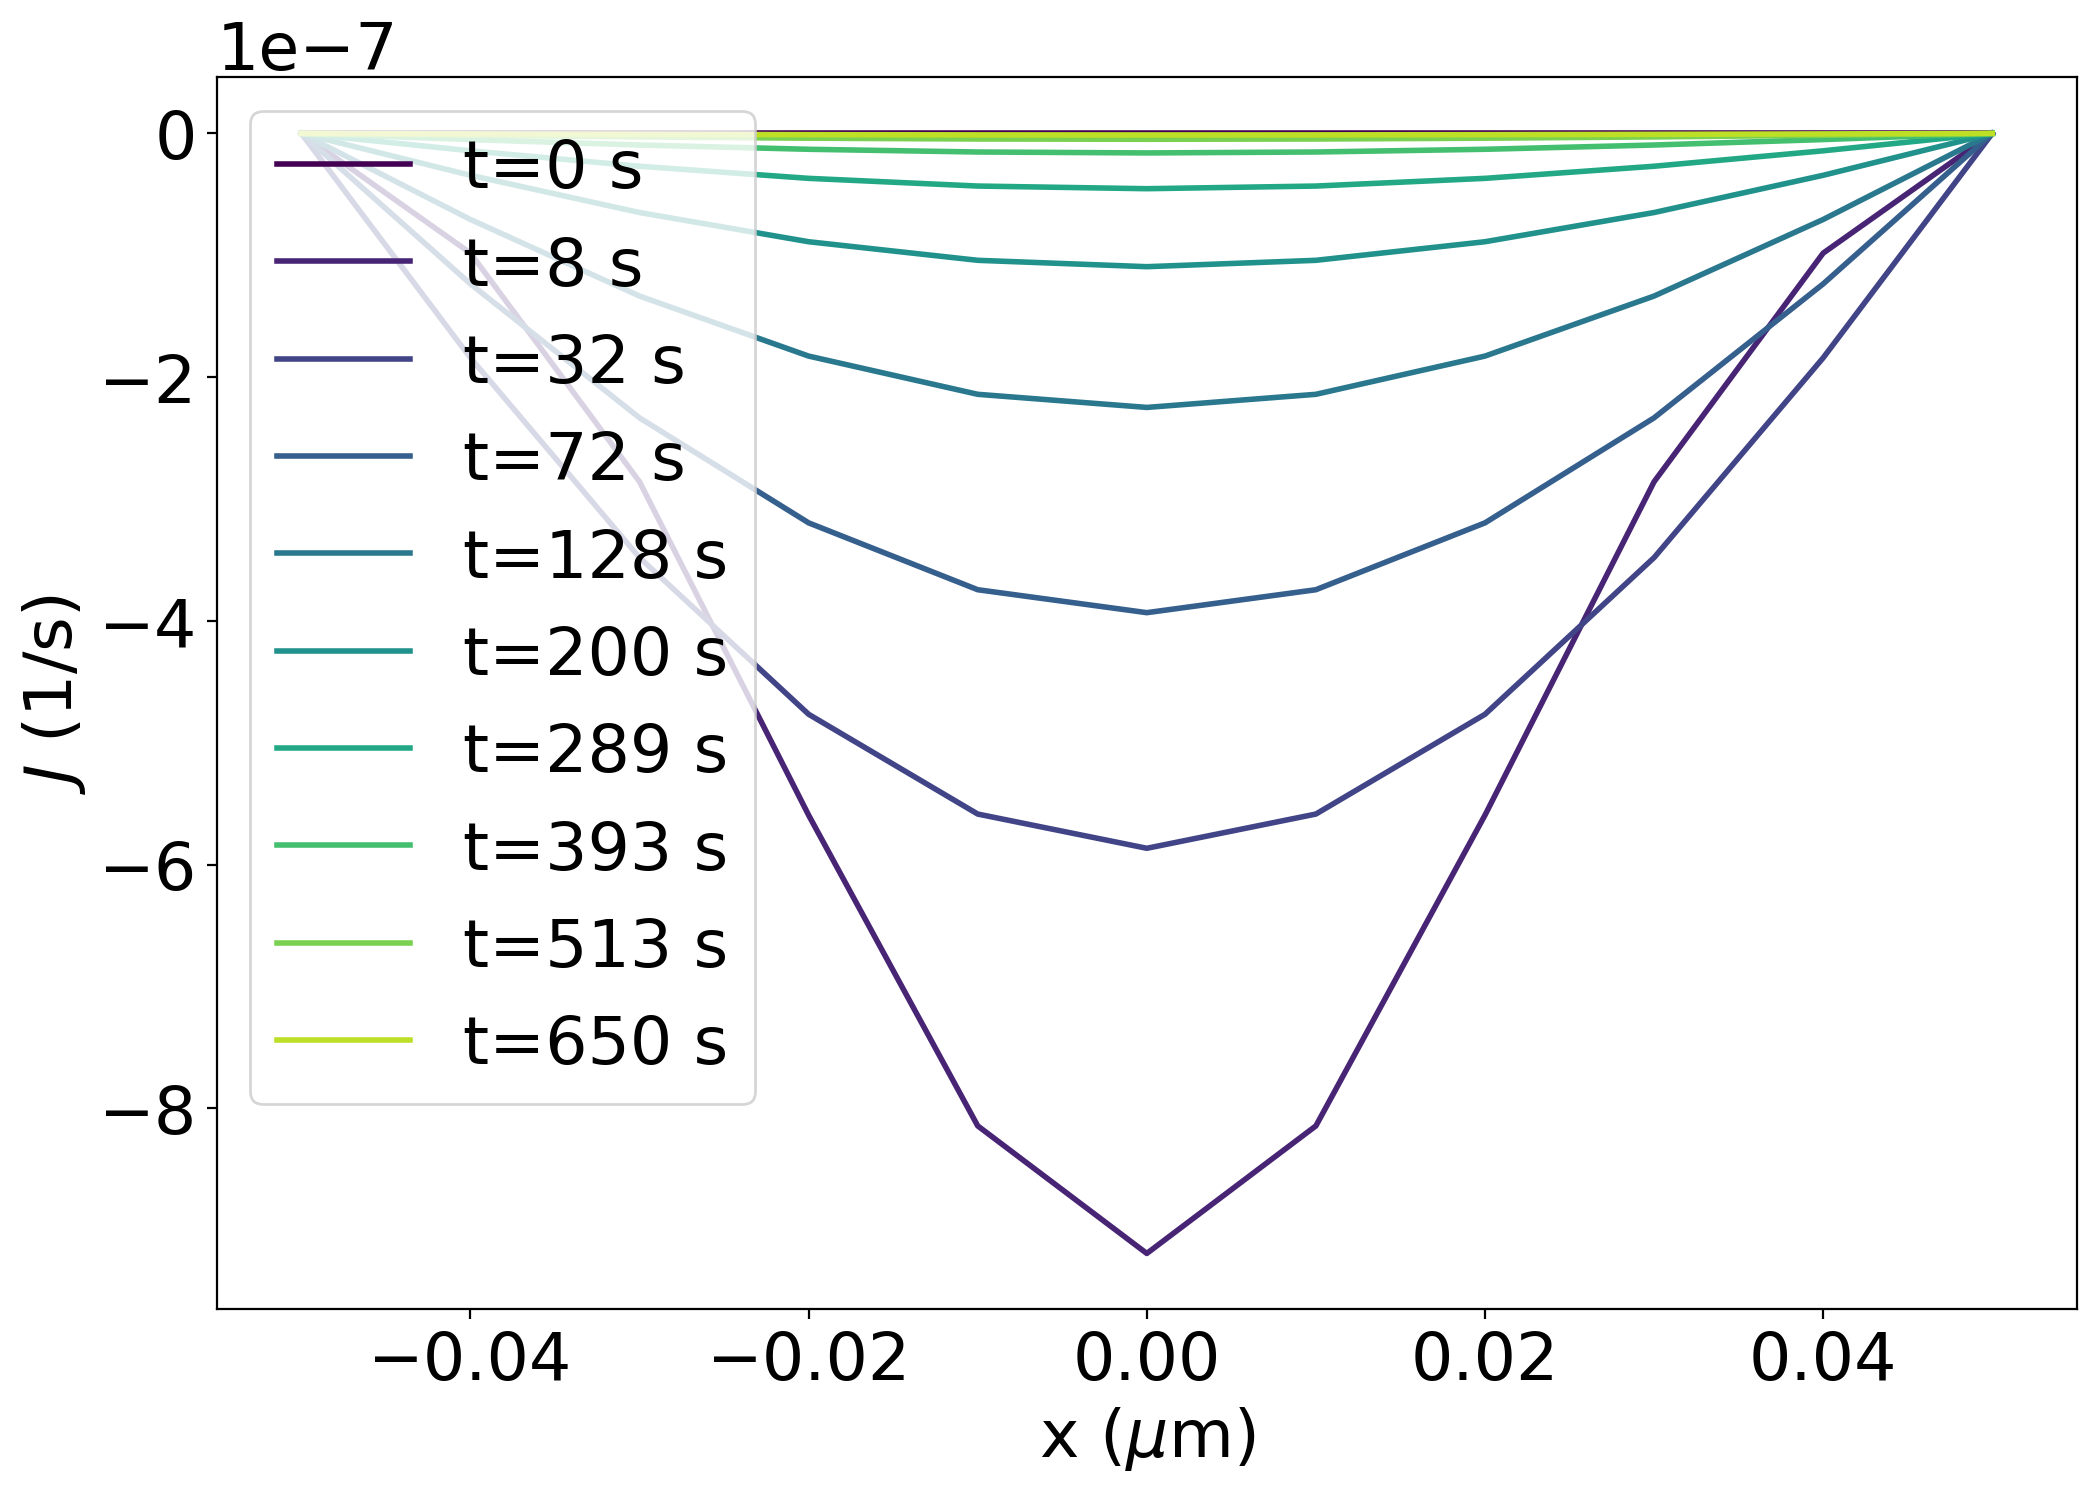

Simulation with N_gbn=21, delta=0.005, dtmax=1000.0000000000001
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        0.0000000000000000        1.0000000000000000       0.10000000000000001               21
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)      500000   1000.0000000000000        480.76376504940208        3.4169964660731916E-015   5.3686449755340517E-006           0           1  -1.7976931348623157E+308


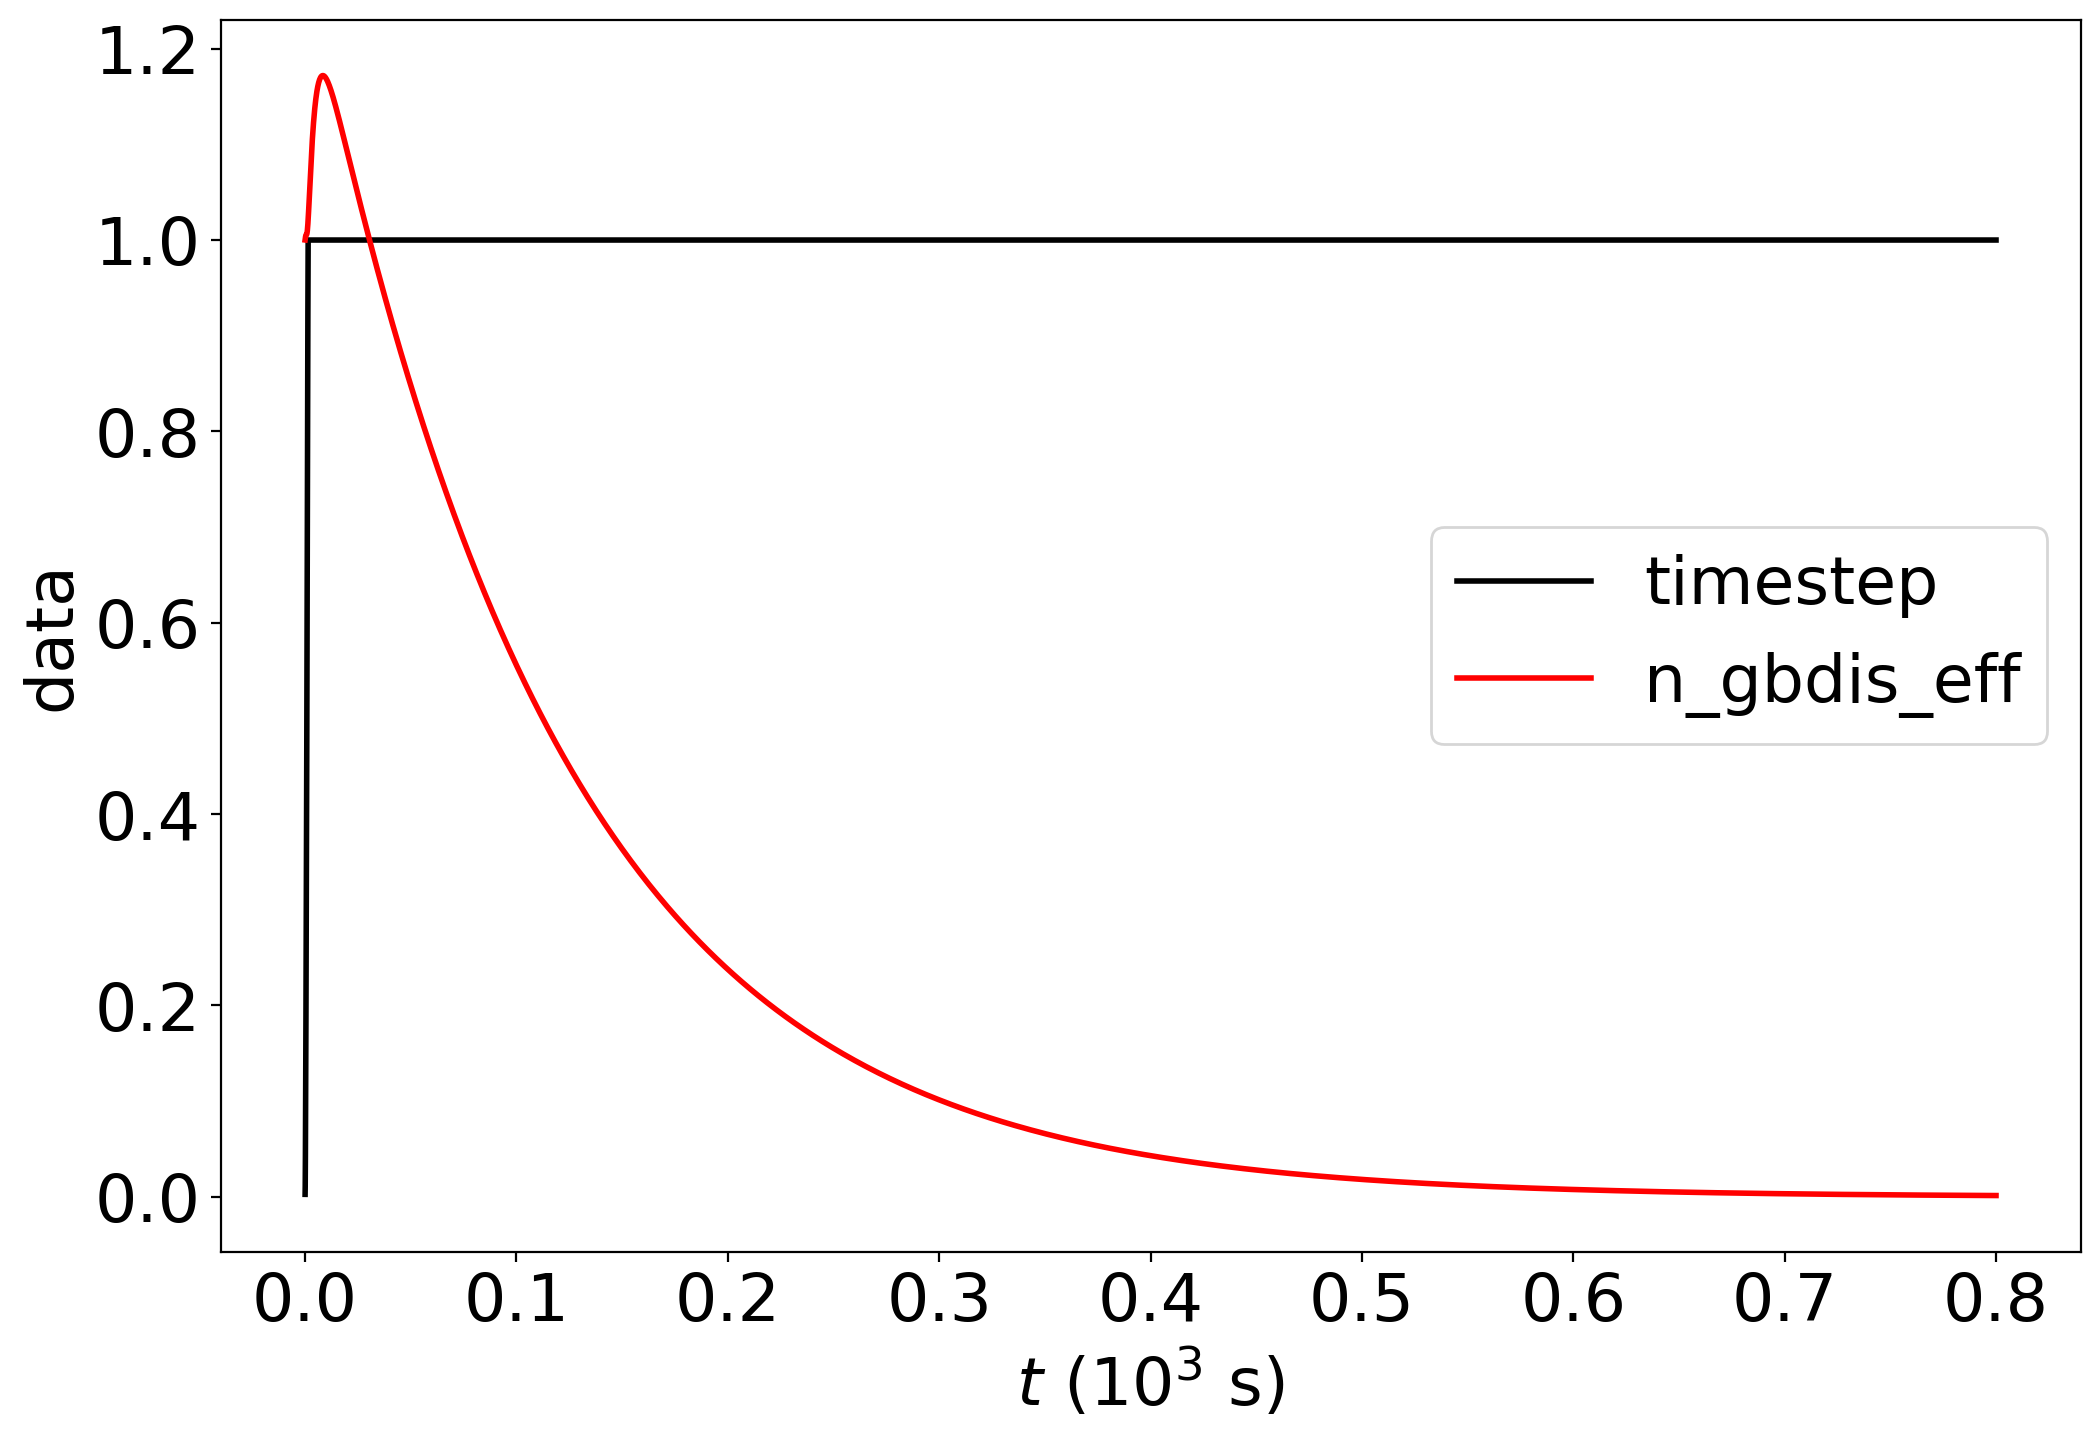

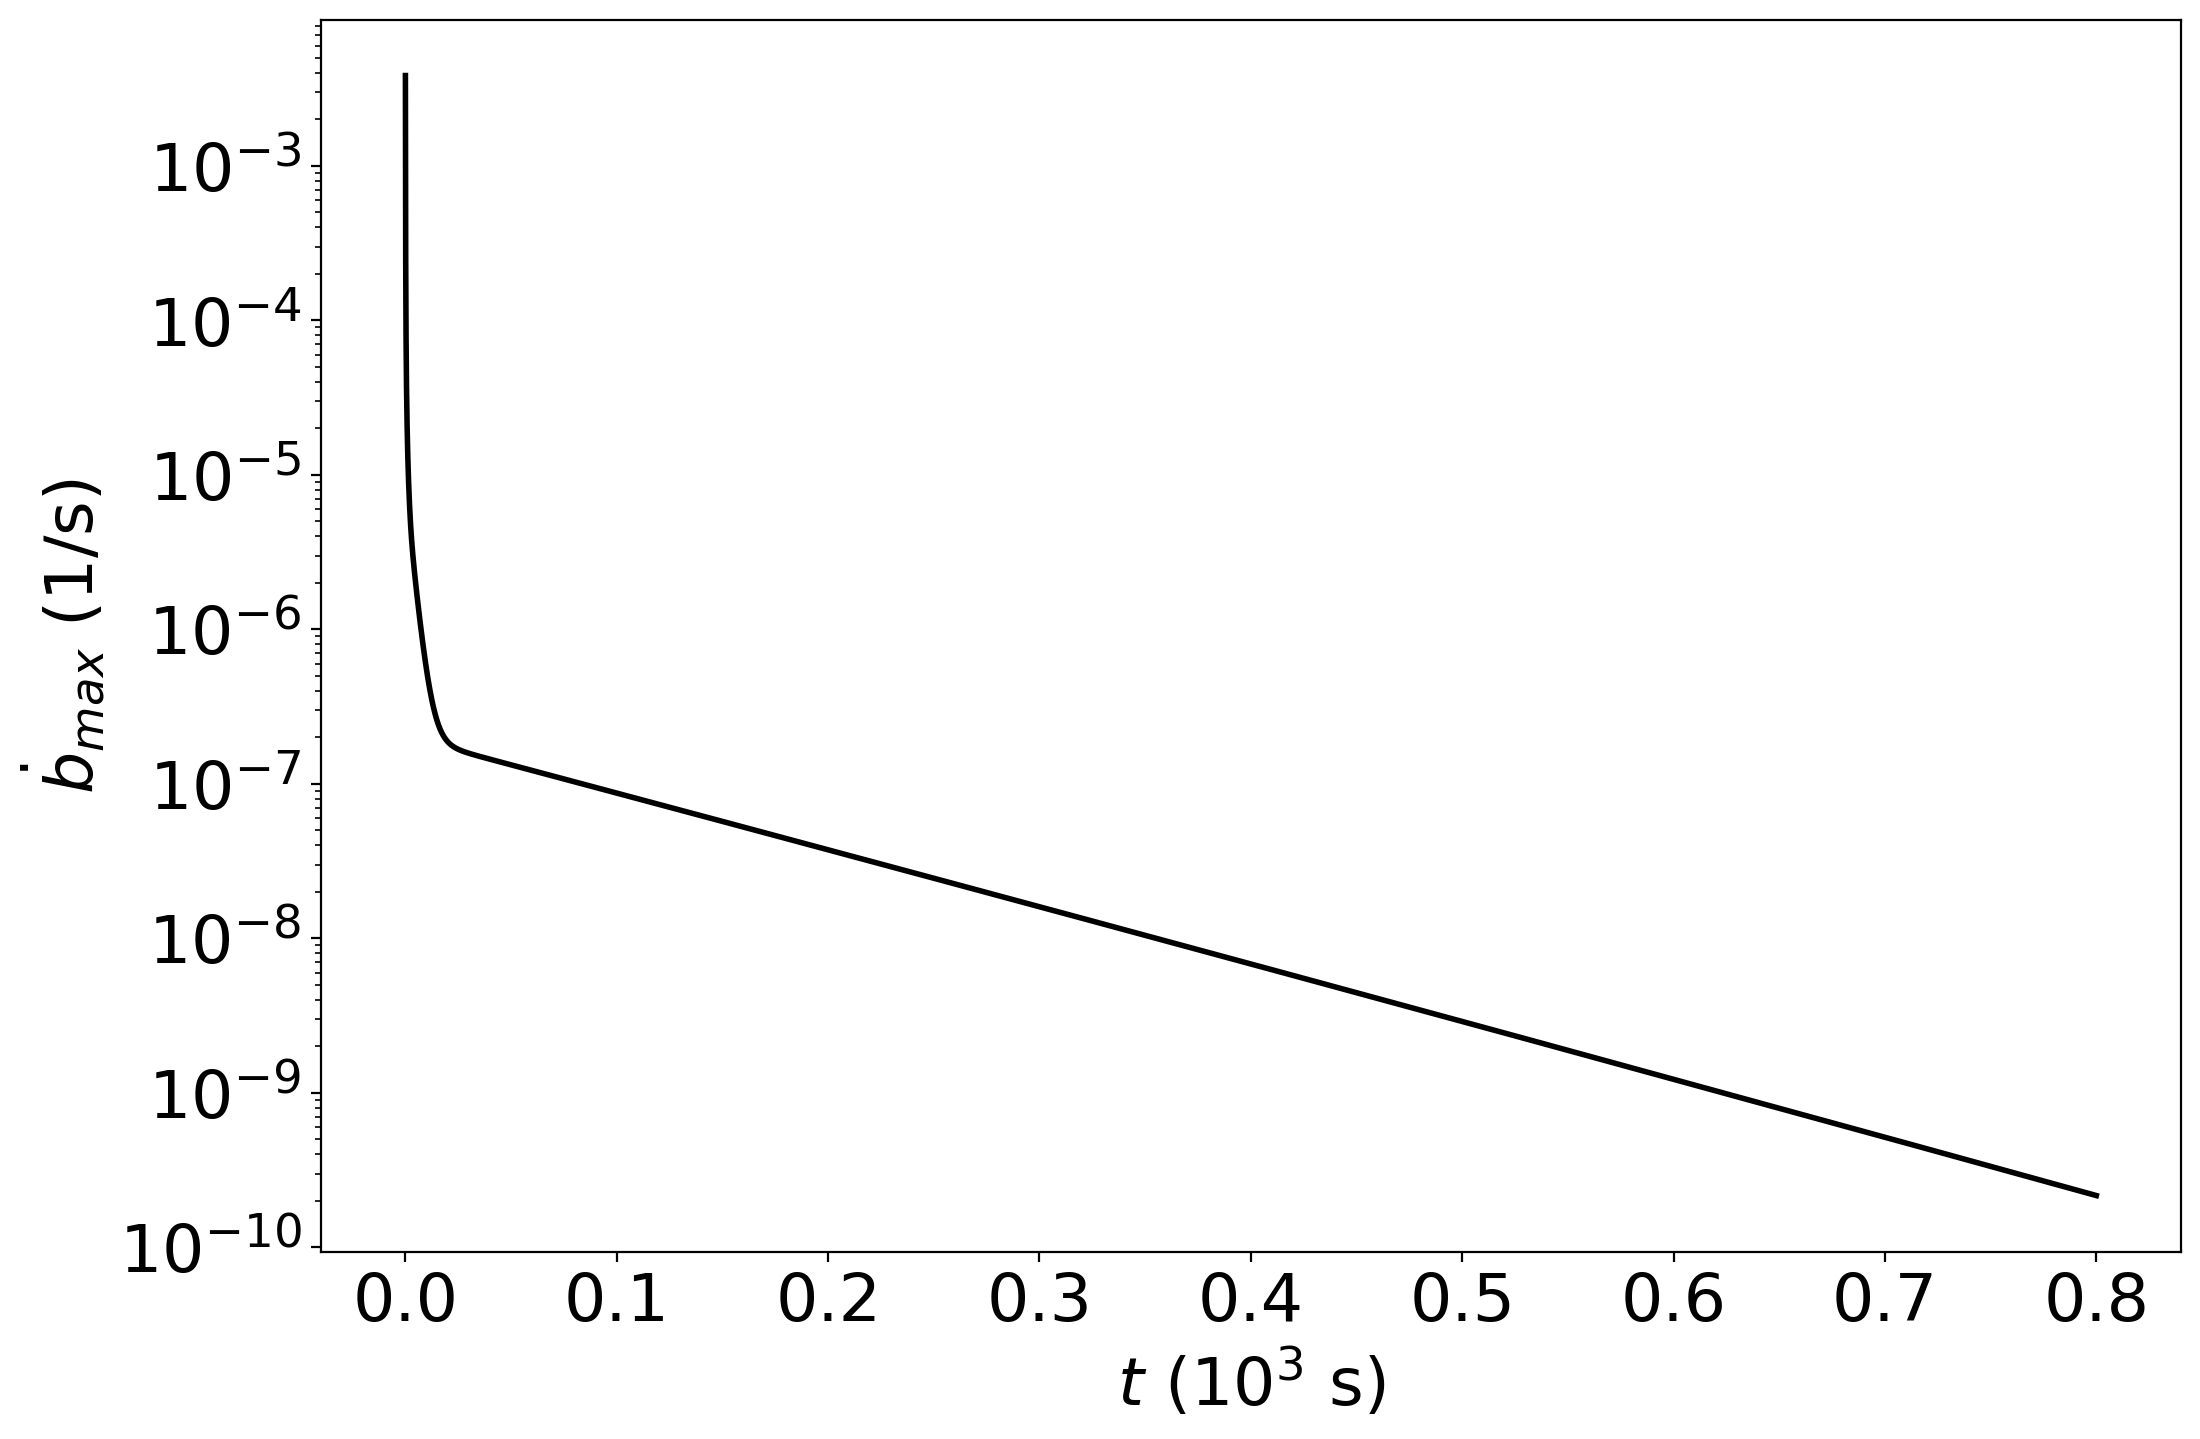

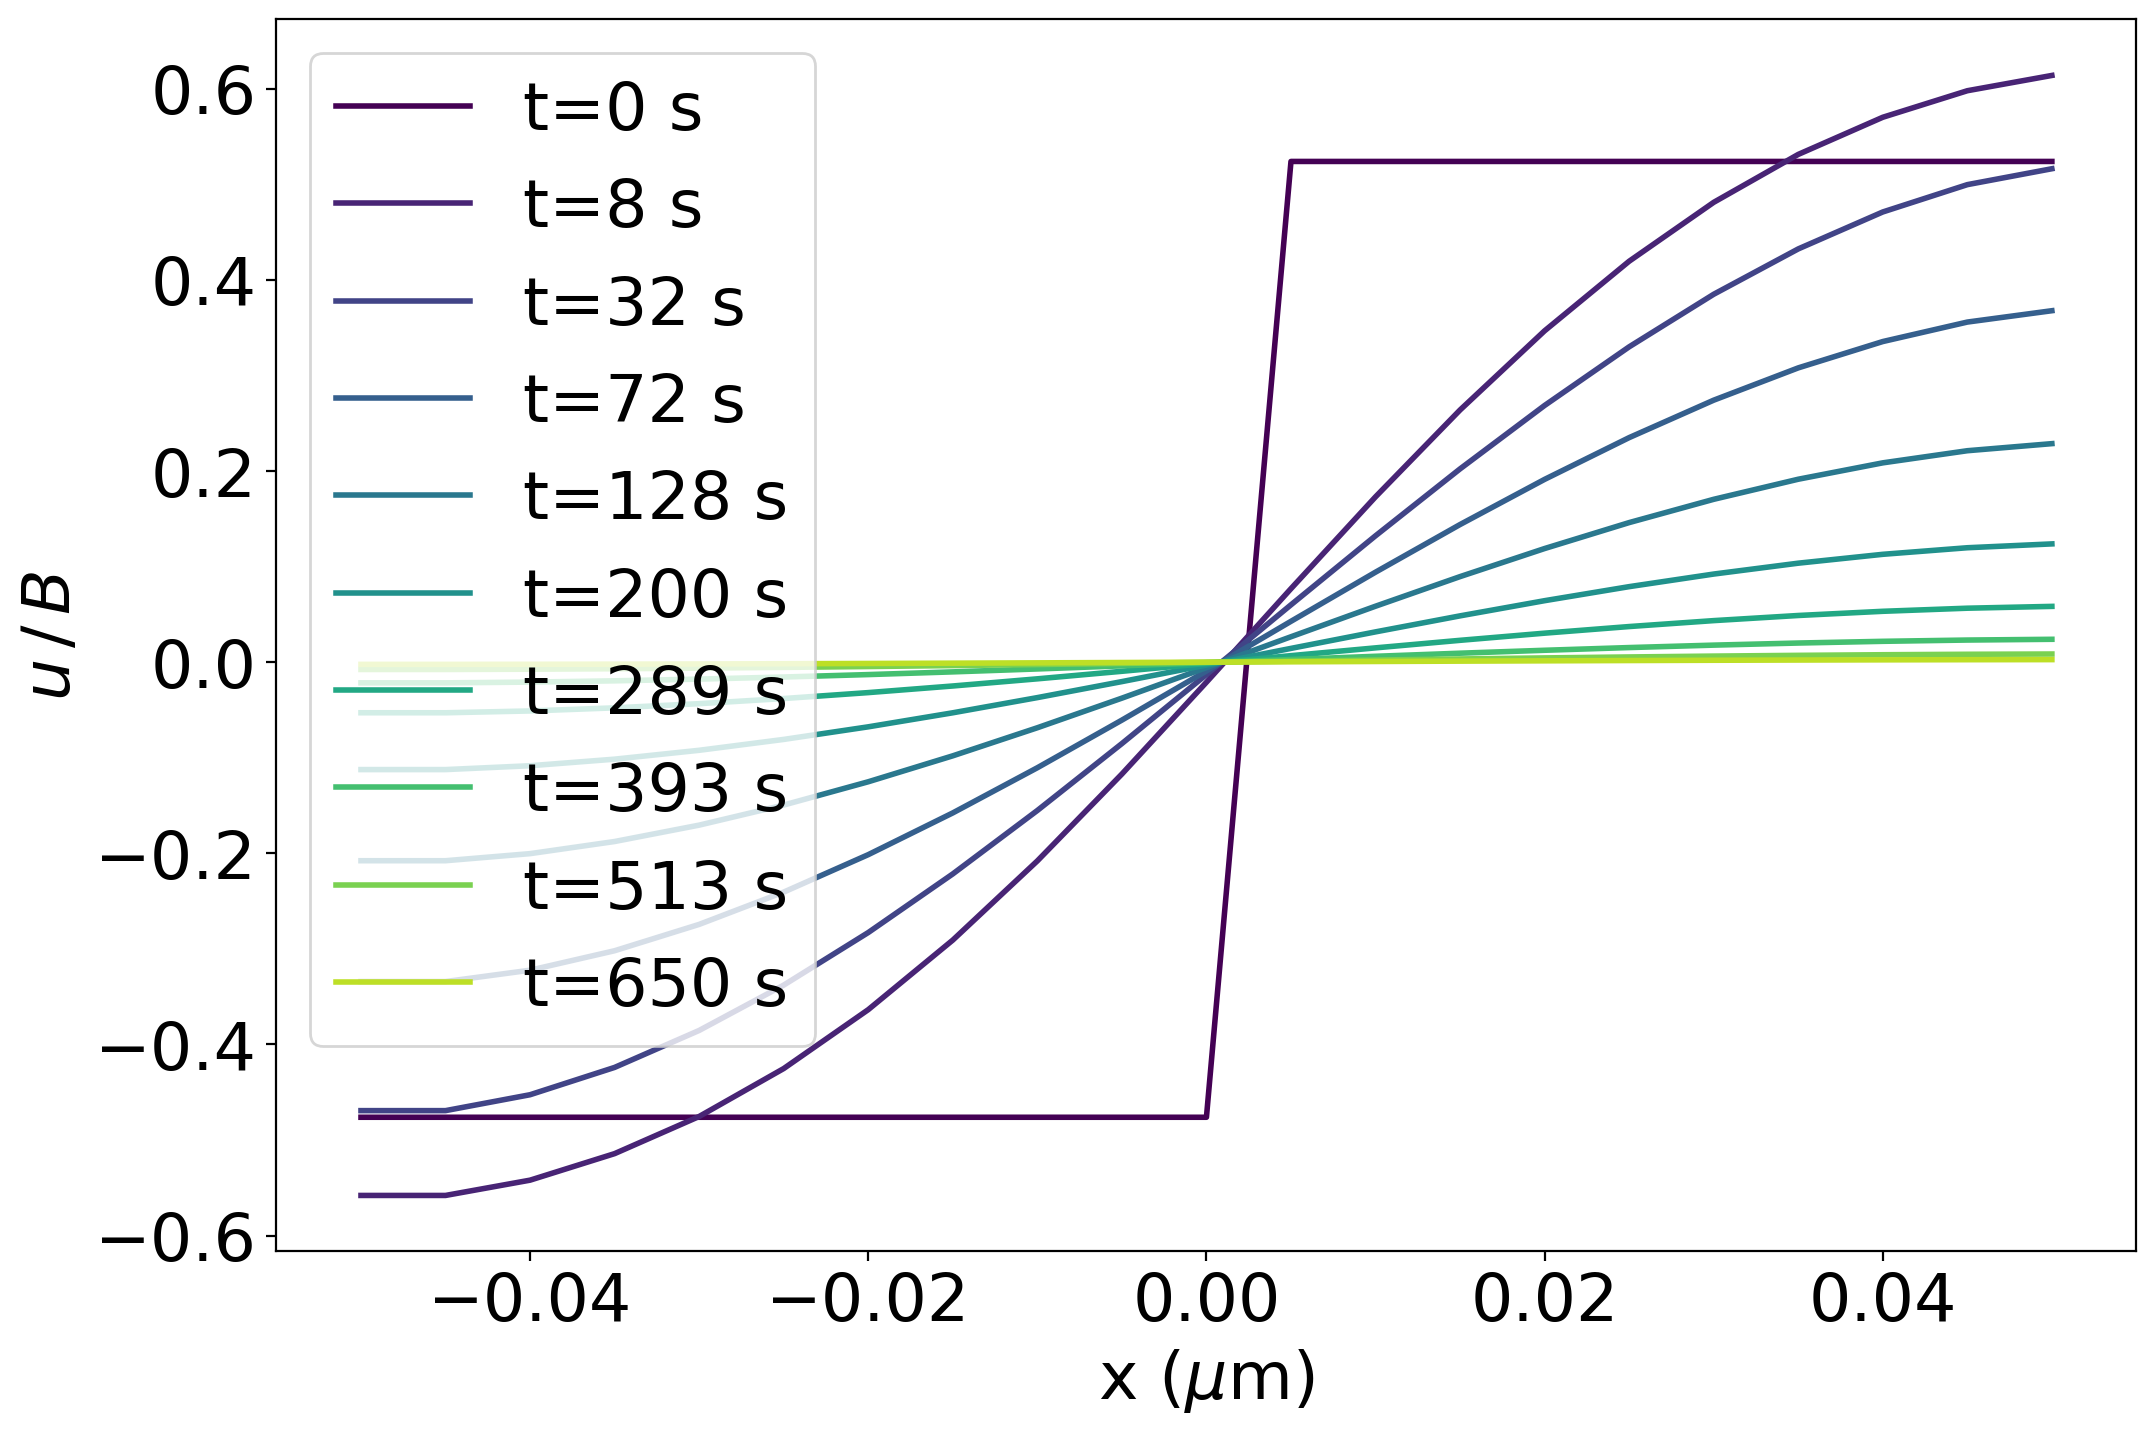

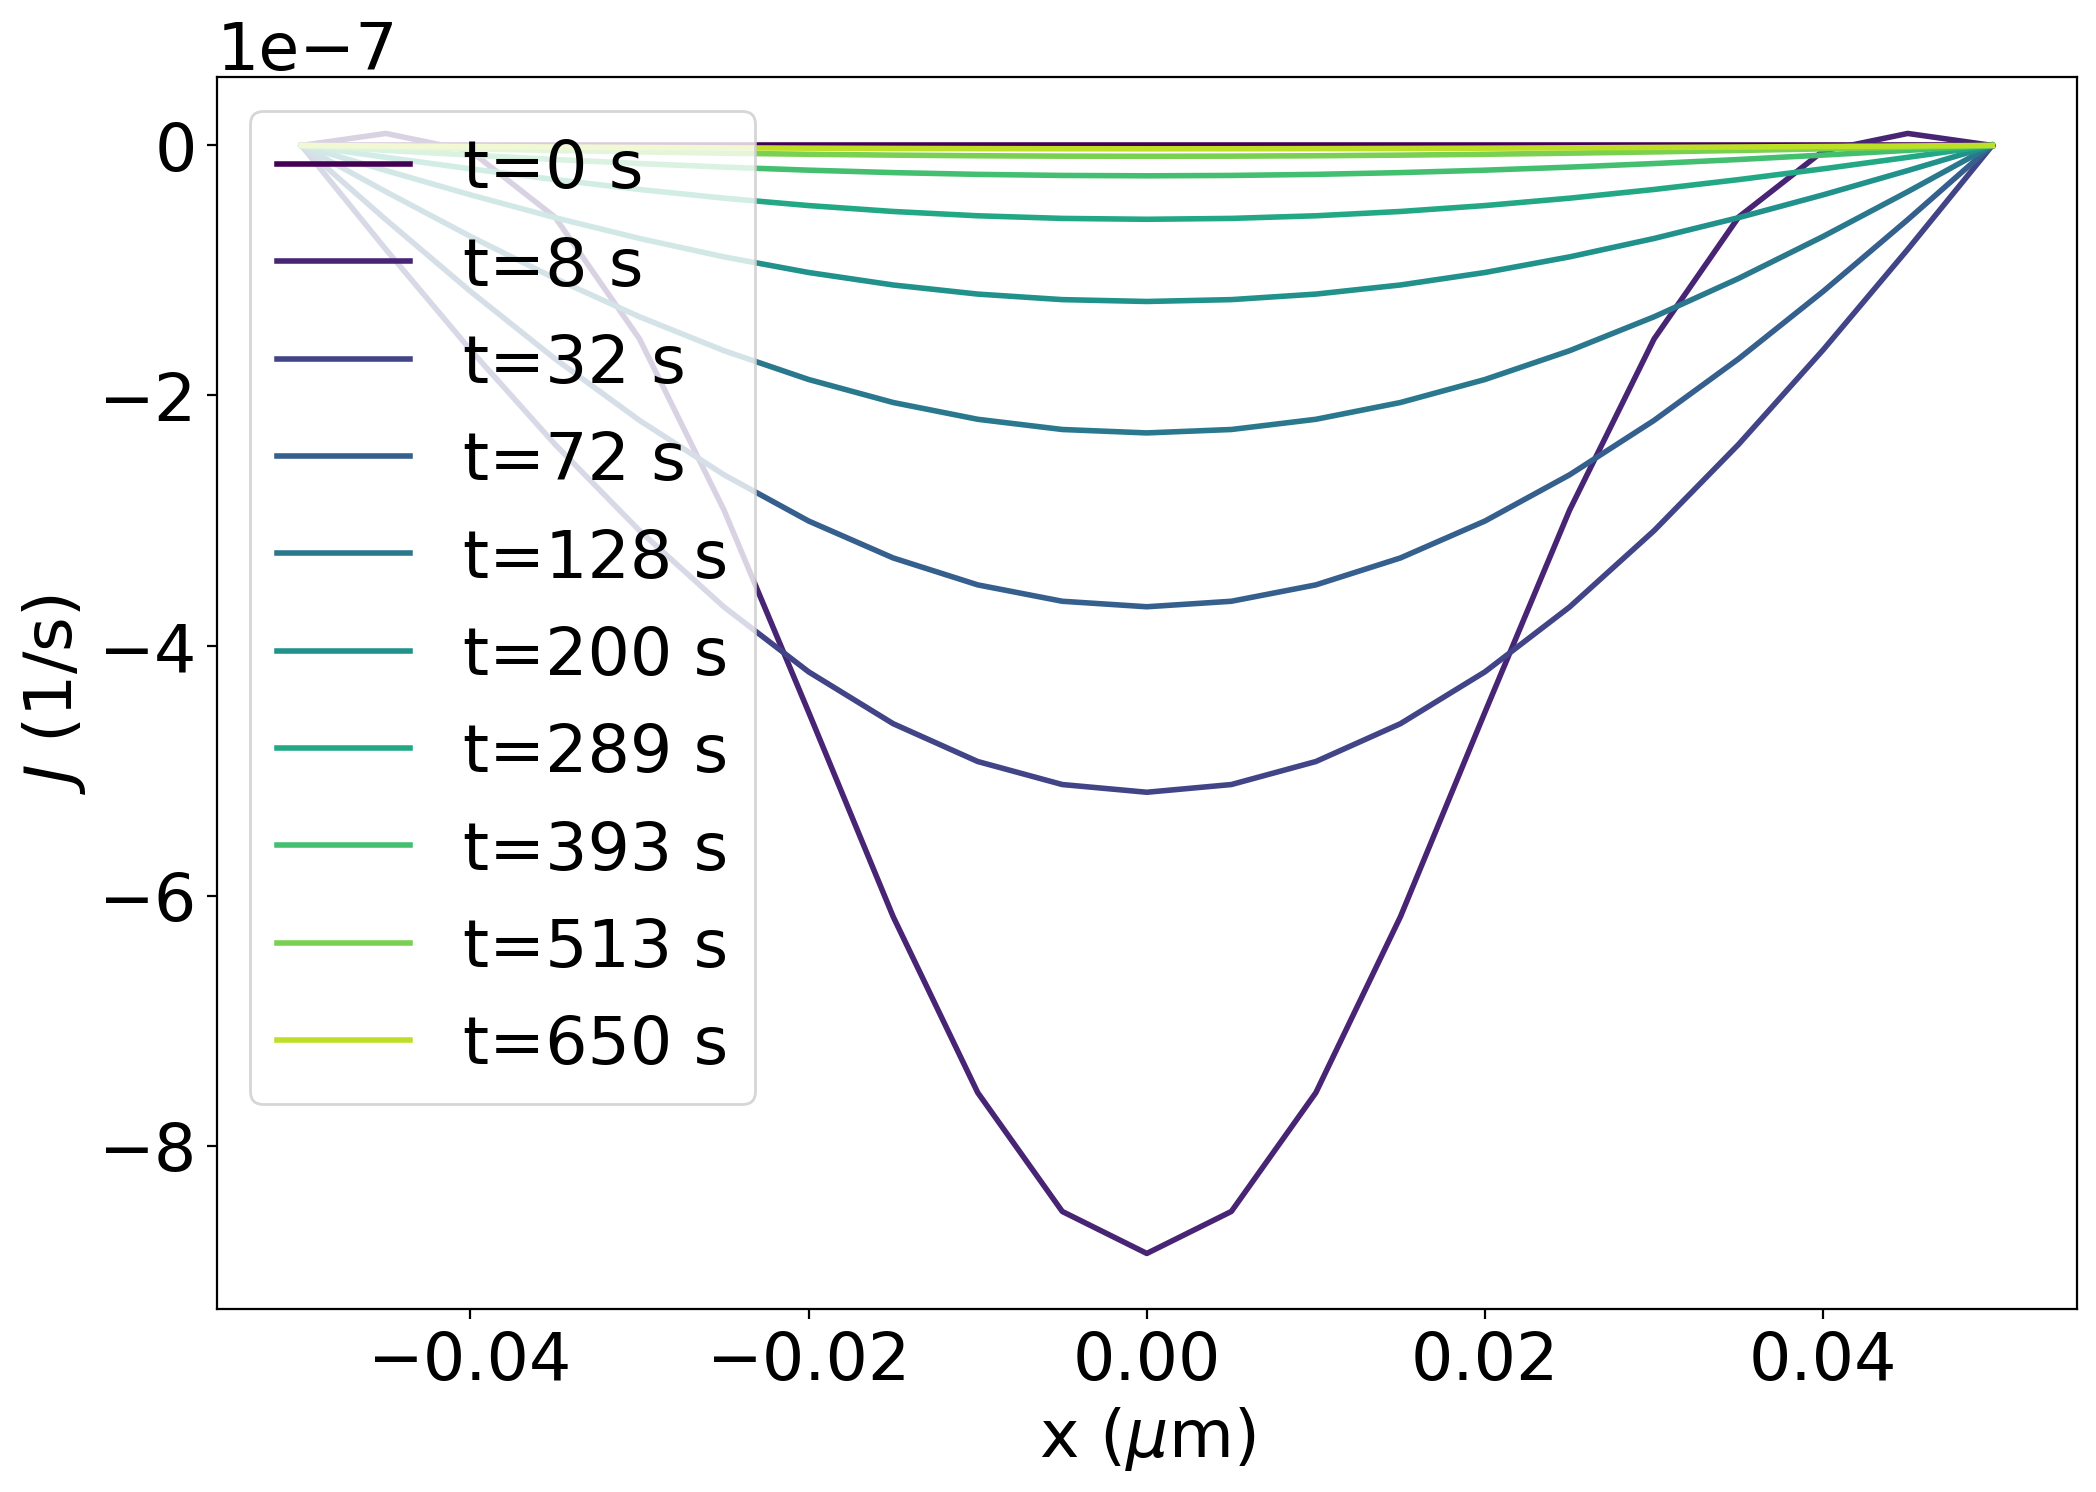

Simulation with N_gbn=31, delta=0.0033333333333333335, dtmax=5062.5
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        0.0000000000000000        1.0000000000000000       0.10000000000000001               31


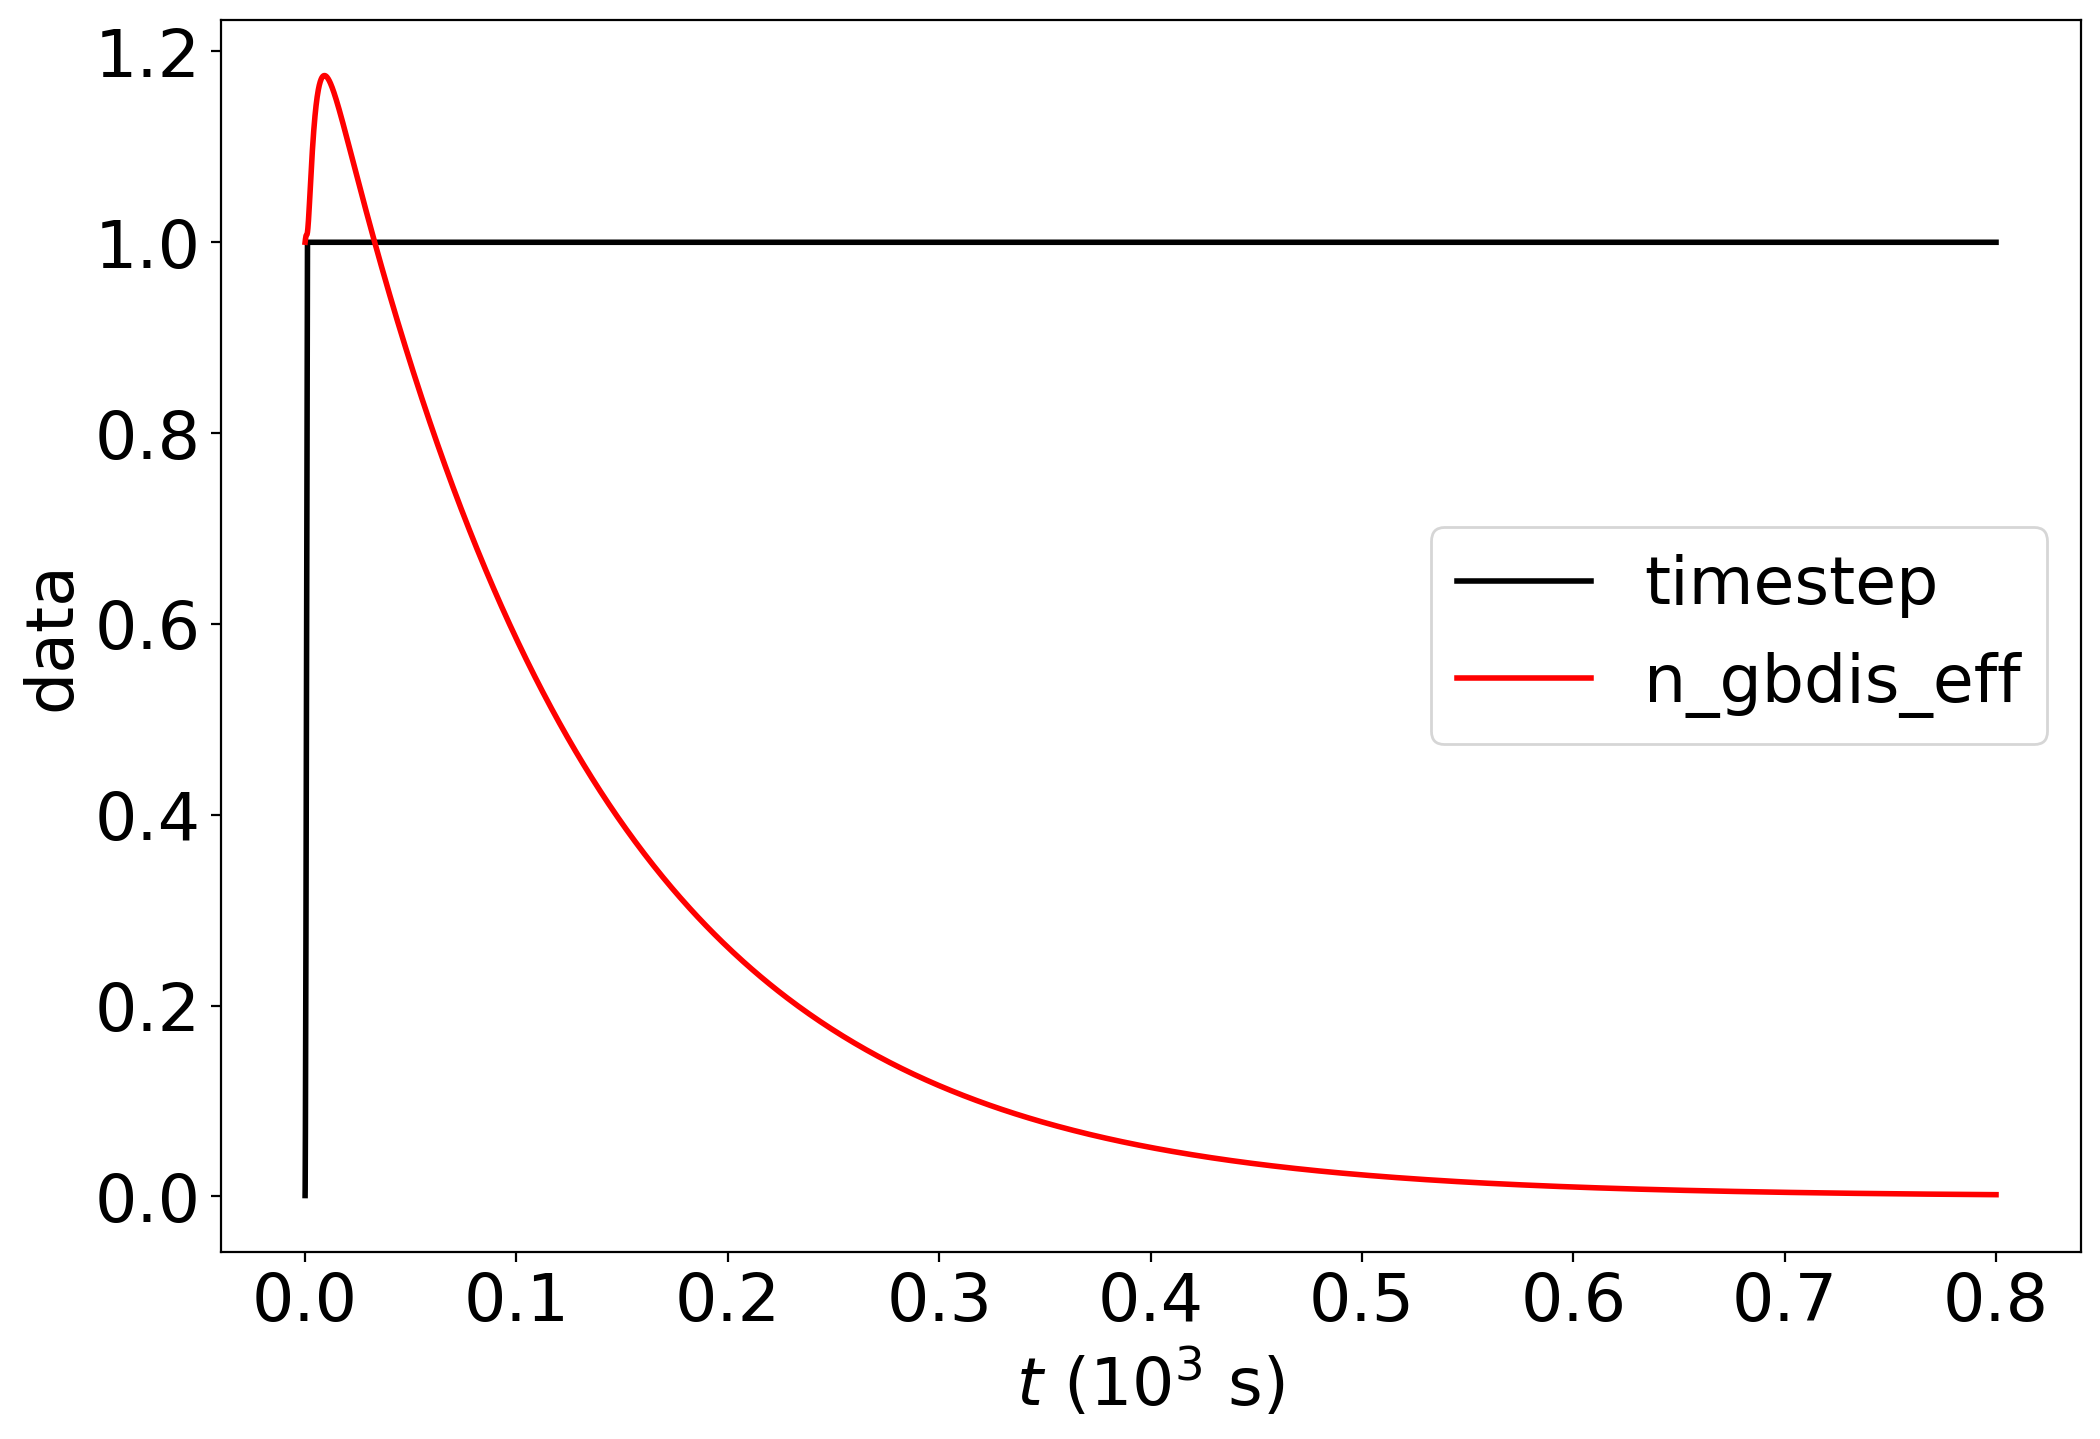

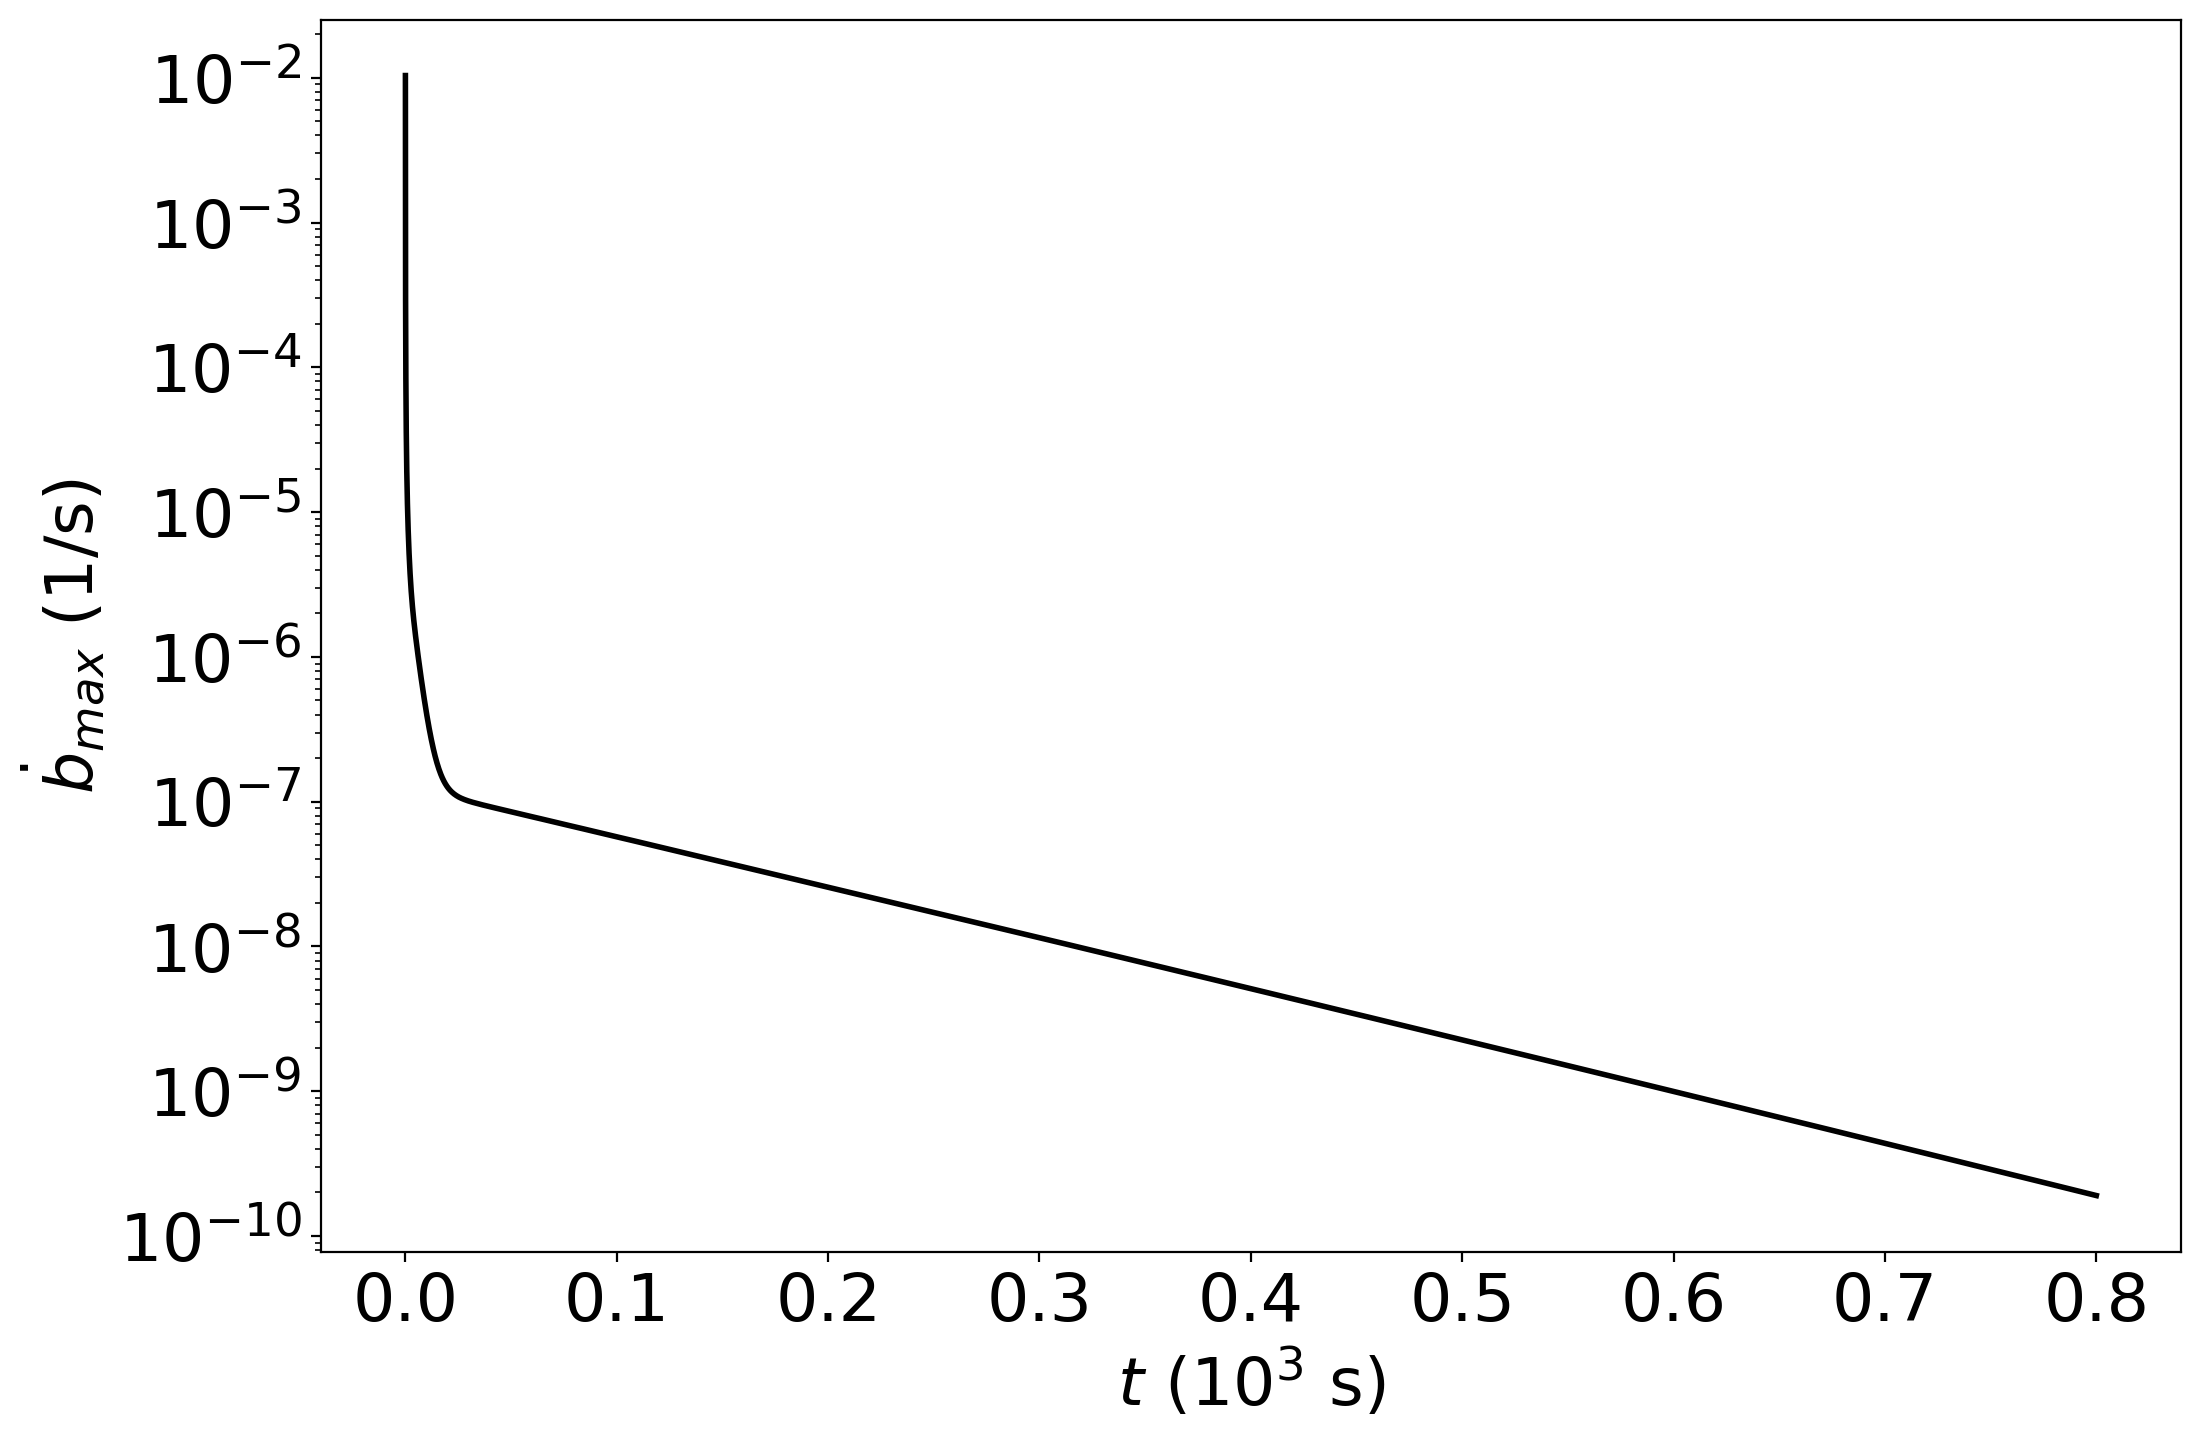

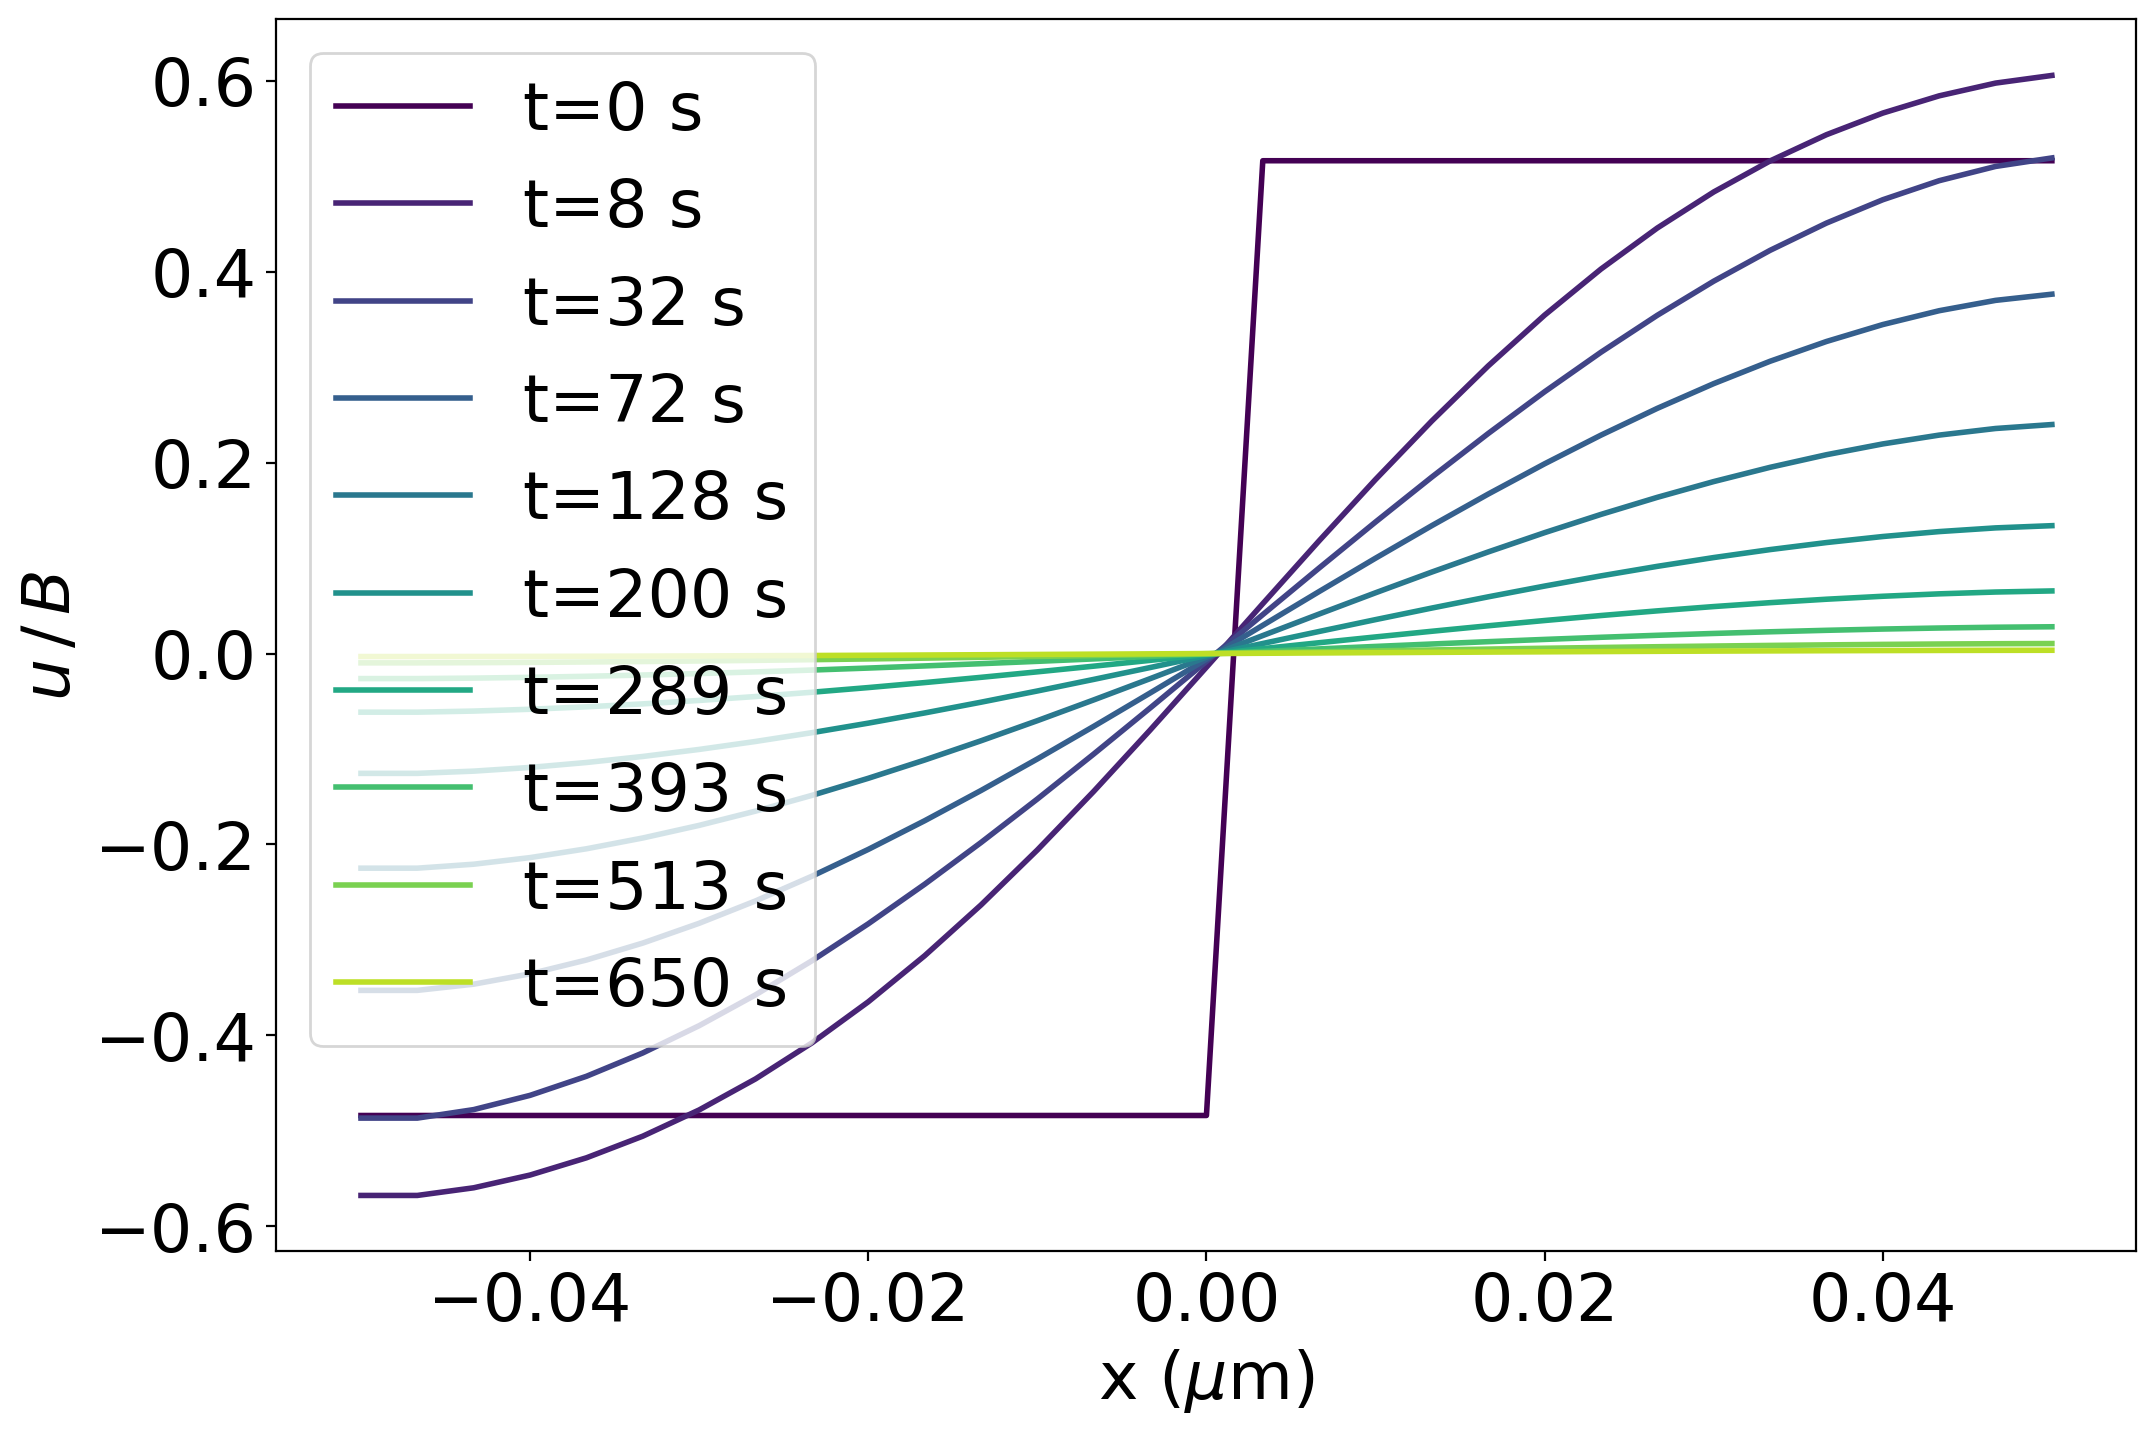

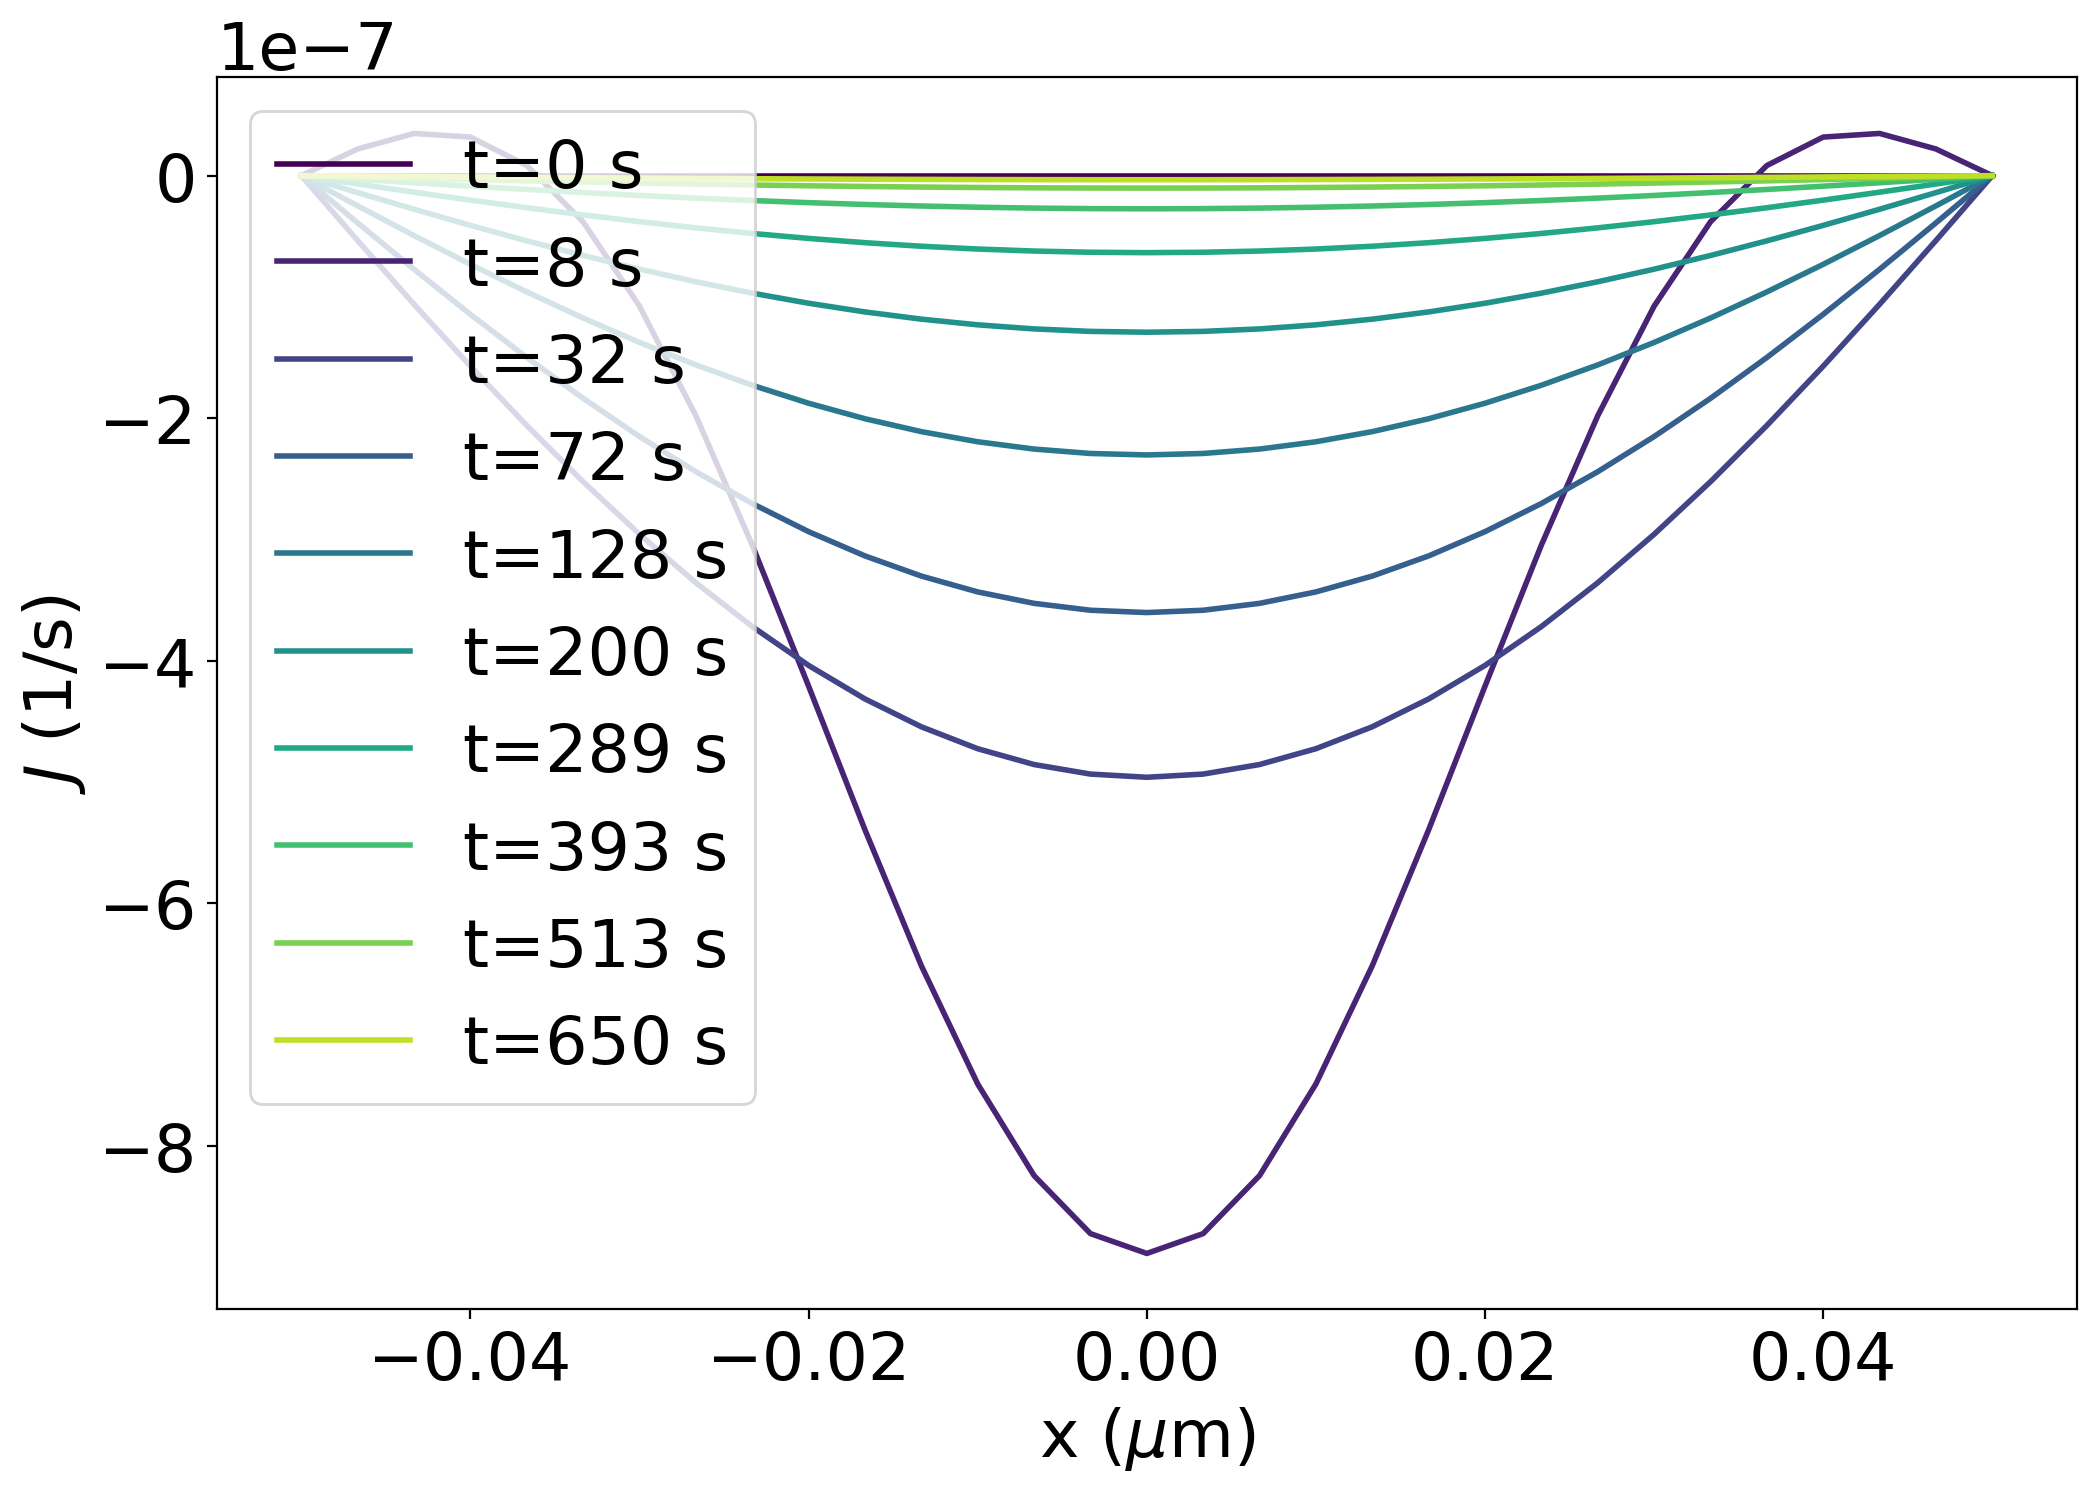

Simulation with N_gbn=41, delta=0.0025, dtmax=16000.000000000002
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        0.0000000000000000        1.0000000000000000       0.10000000000000001               41


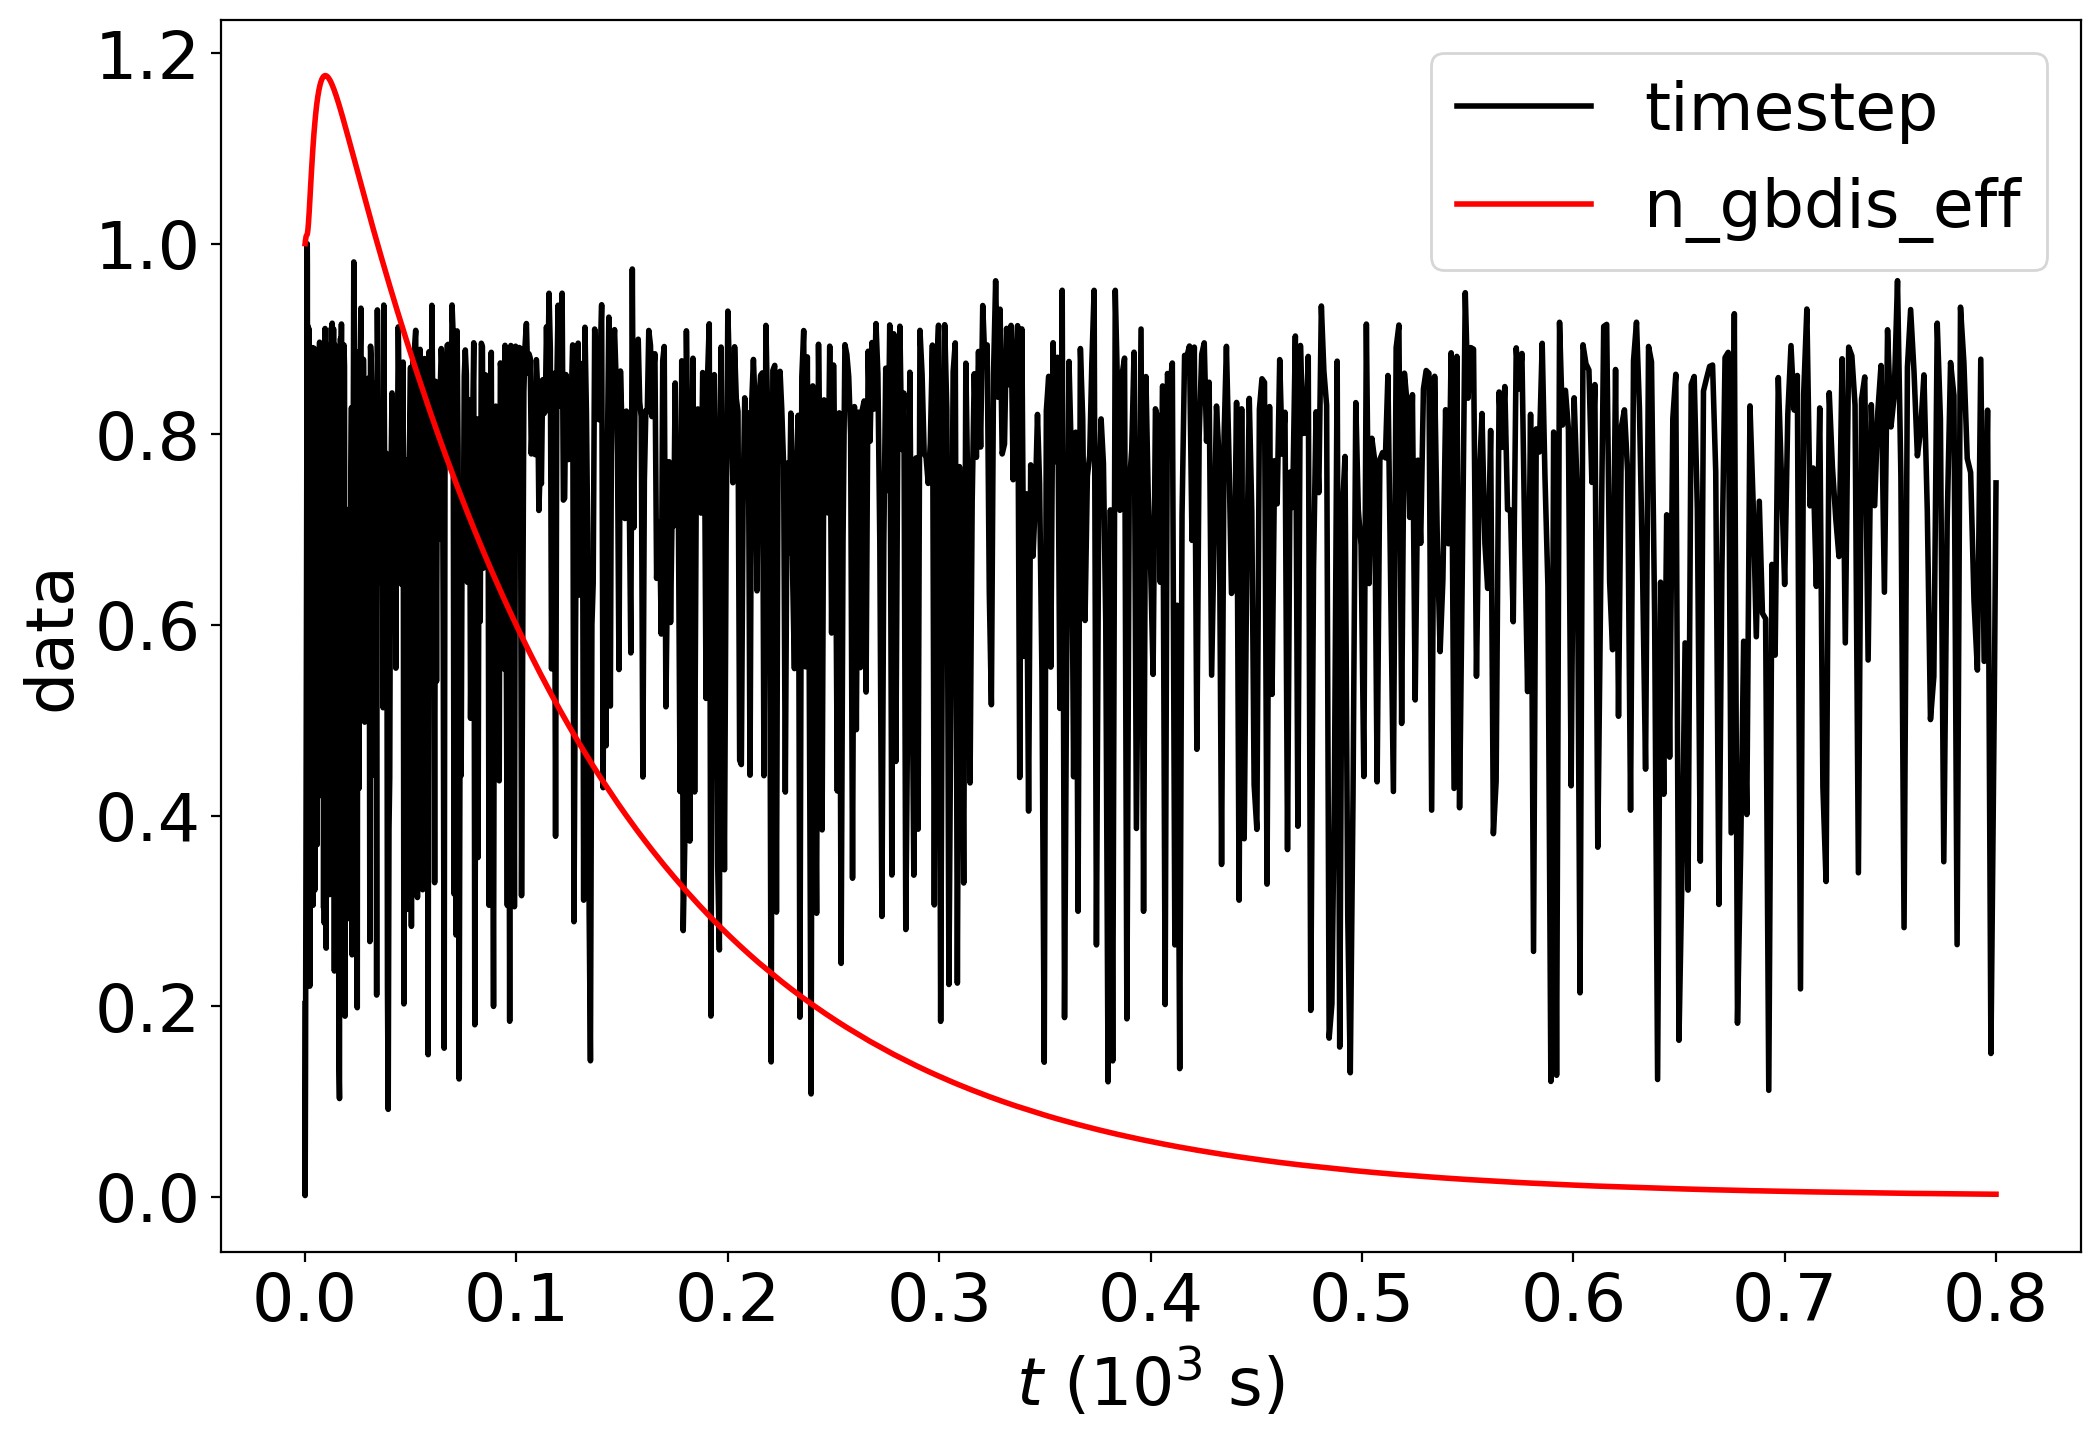

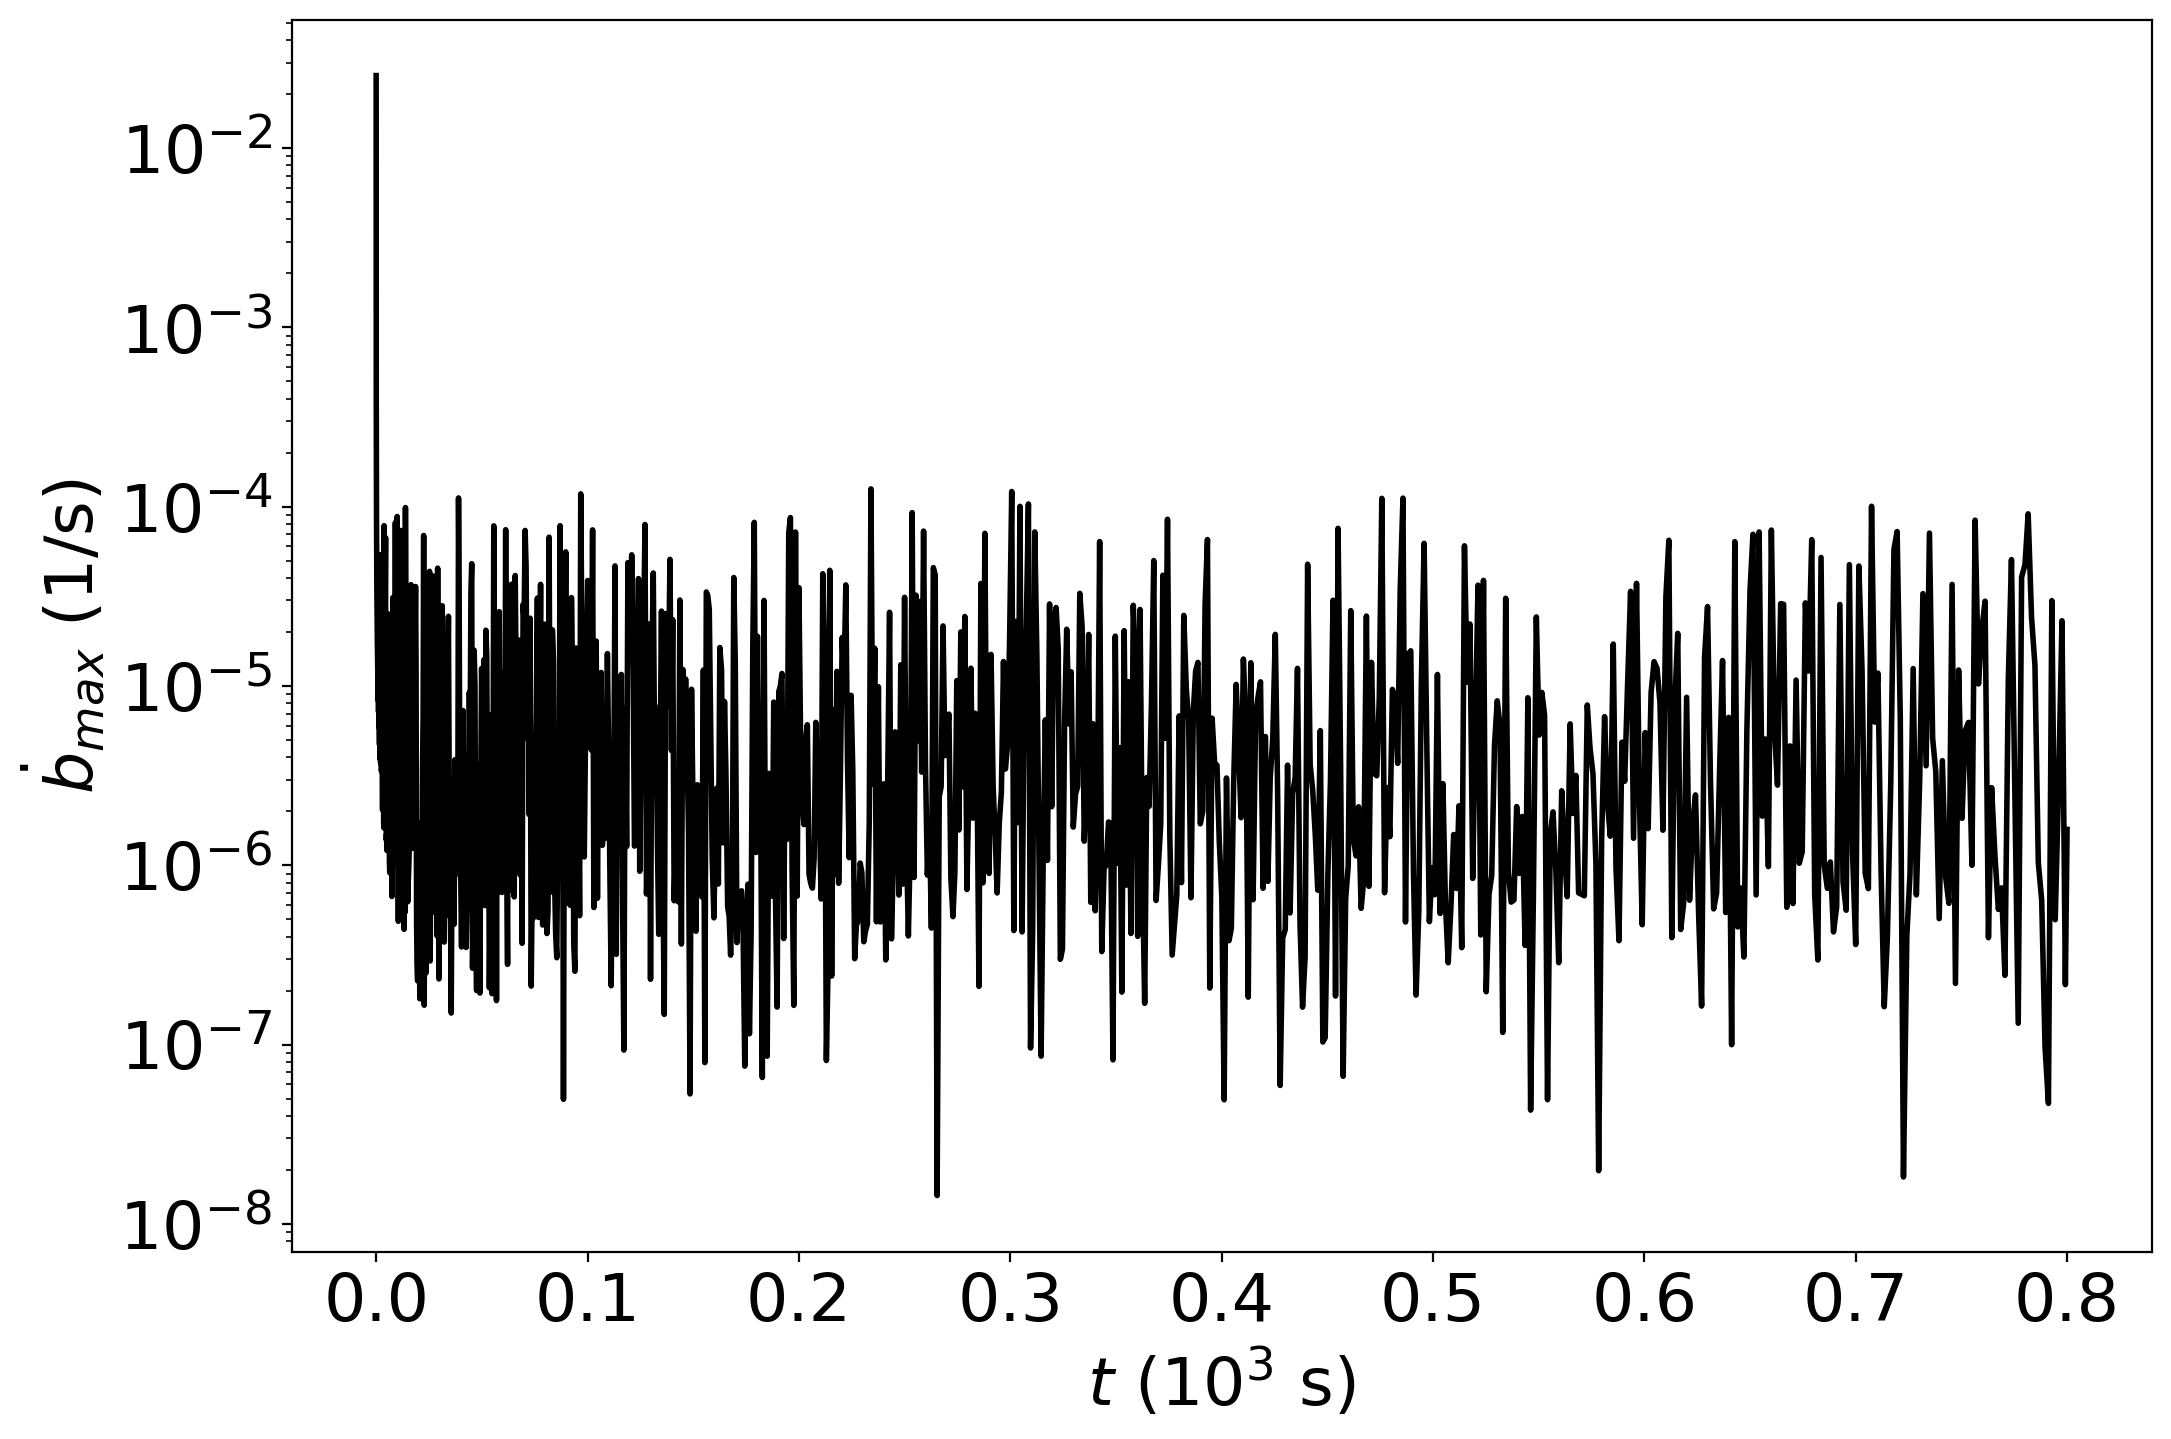

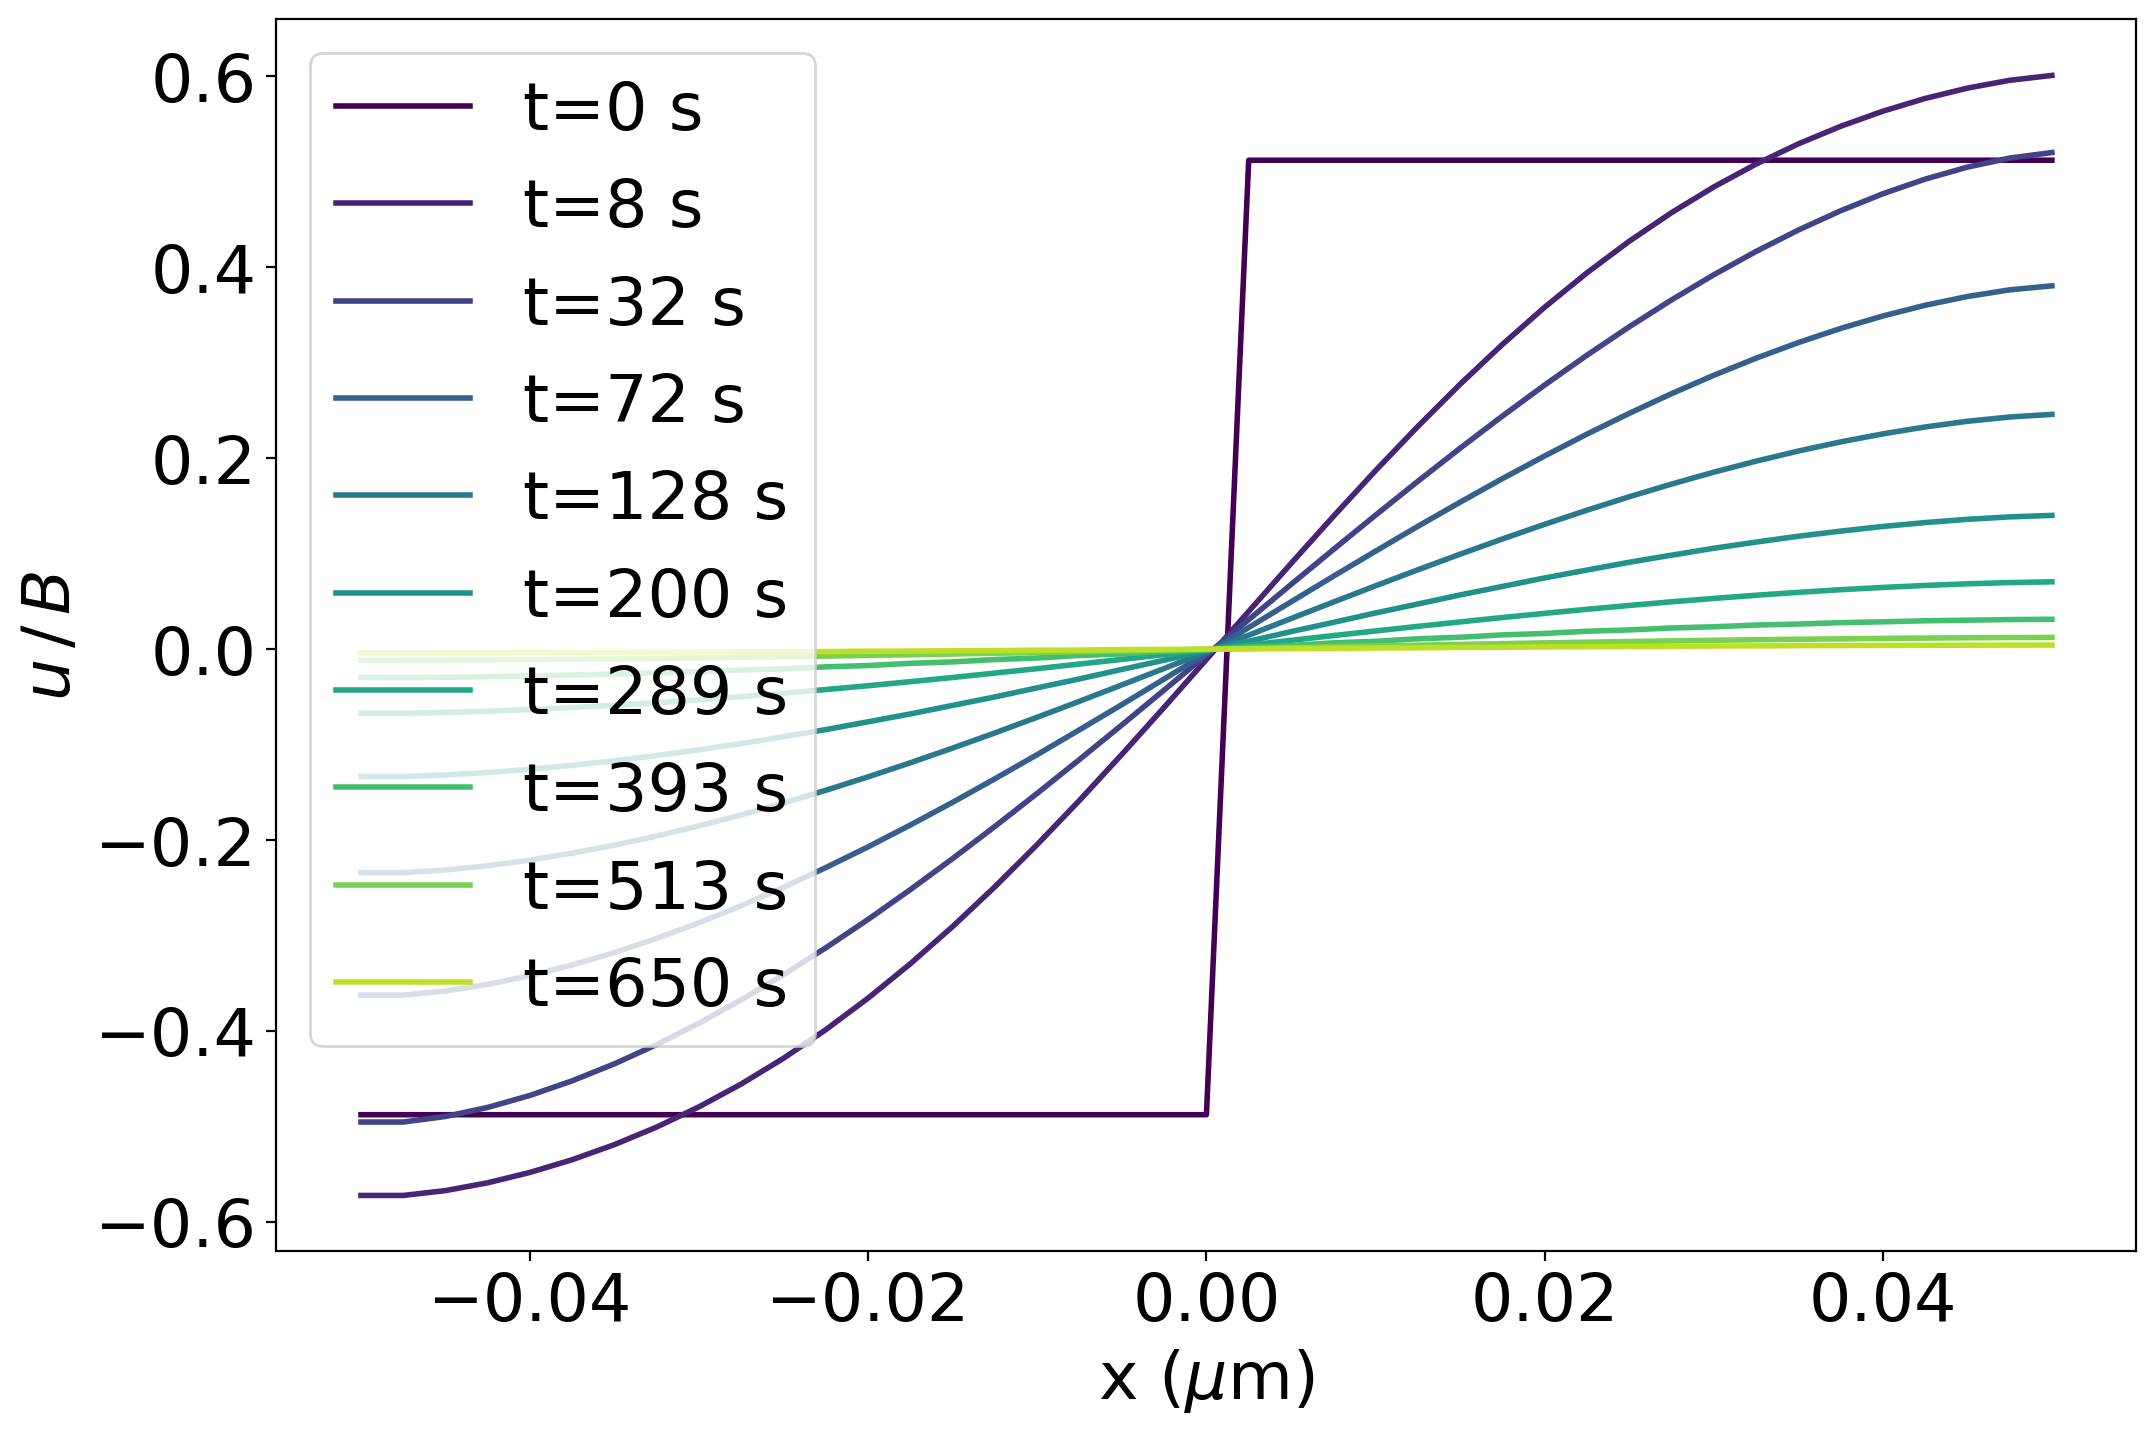

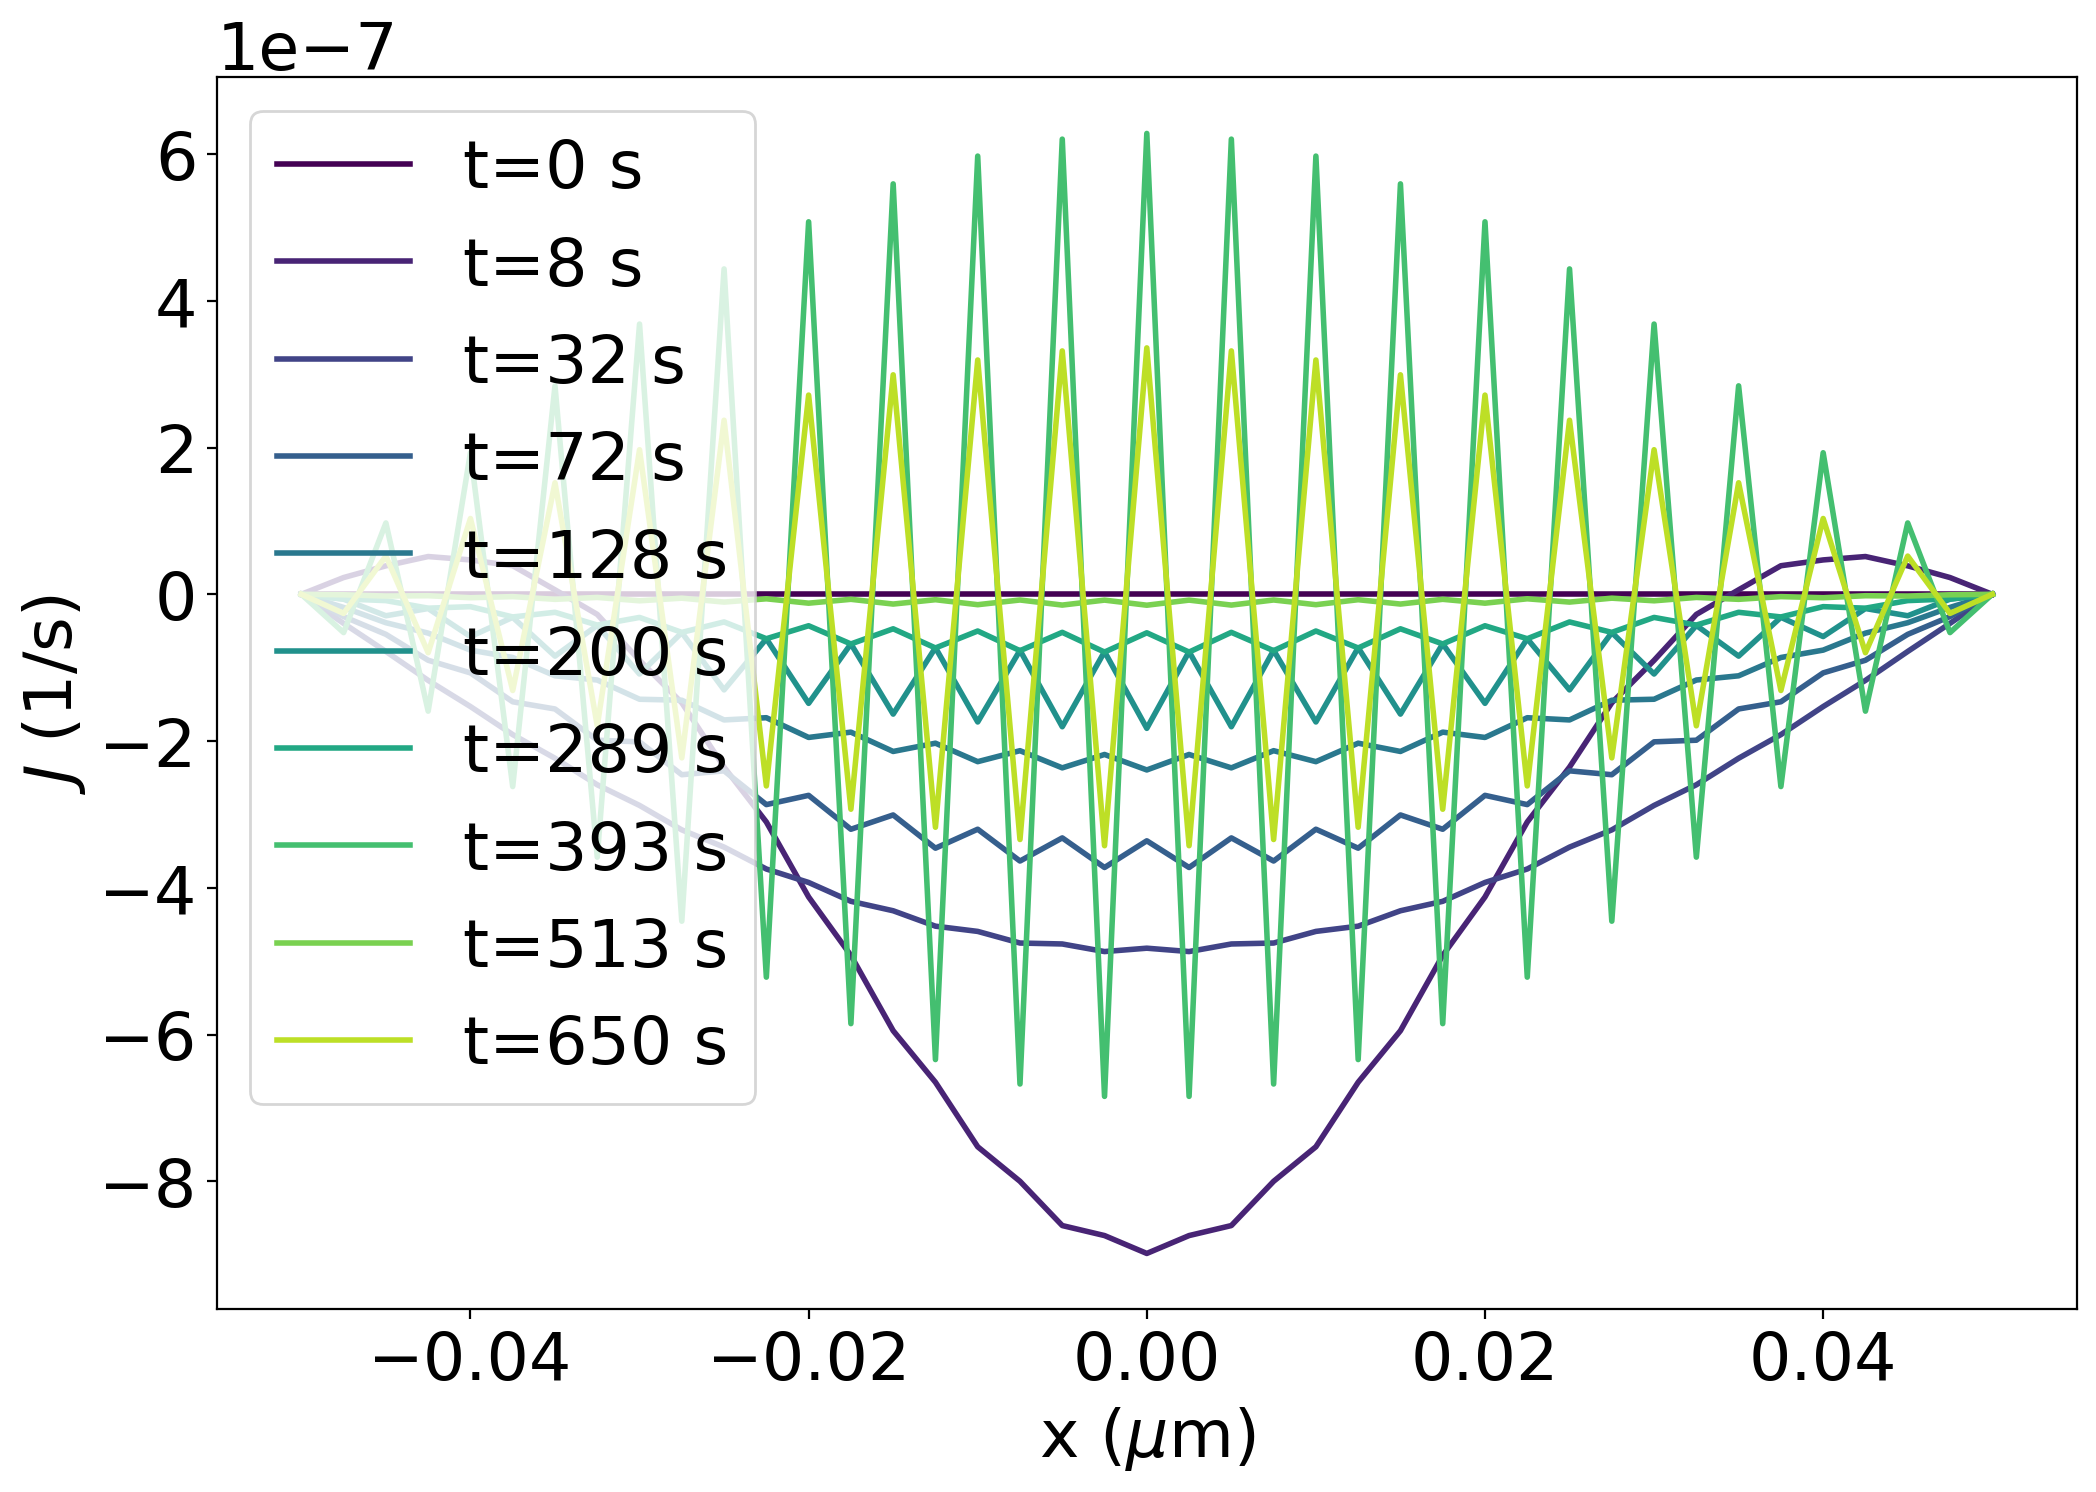

In [2]:
temp = 900.0
tau0 = 0.0
lgb = 0.1
grain_size = 1.0
maxout = 1000
tfin = 8.e8
niter = 50_000_000
#ngbn = 41 #int(lgb/delta)
#if ngbn % 2 == 0: ngbn += 1
ngb_list = [11, 21, 31, 41]
Np = len(ngb_list)
bdmax = np.zeros((Np, maxout))
btot = np.zeros((Np, maxout))
sim_time = np.zeros((Np, maxout))
nit = np.zeros(Np, dtype=int)
Ngb_list = np.zeros(Np, dtype=int)
for i, ngbn in enumerate(ngb_list):
    delta = lgb/(ngbn - 1)  # 0.005
    dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
    print(f"Simulation with N_gbn={ngbn}, delta={delta}, dtmax={dtmax}")
    gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                       Ngbn=ngbn, len_gb_seg=lgb, grain_size=grain_size,
                       tfin=tfin, niter=niter, maxout=maxout,
                       dtmax=dtmax,
                       screenout=True)
    gbdd.run_sim()
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    gbdd.plot_time_series('max_bdot')
    gbdd.plot_field('displacement')
    gbdd.plot_field('flux')
    nit[i] = gbdd.nout
    Ngb_list[i] = gbdd.Ngbn
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    bdmax[i, 0:gbdd.nout] = gbdd.glob_data['max_bdot']
    btot[i, 0:gbdd.nout] = gbdd.glob_data['n_gbdis_eff']

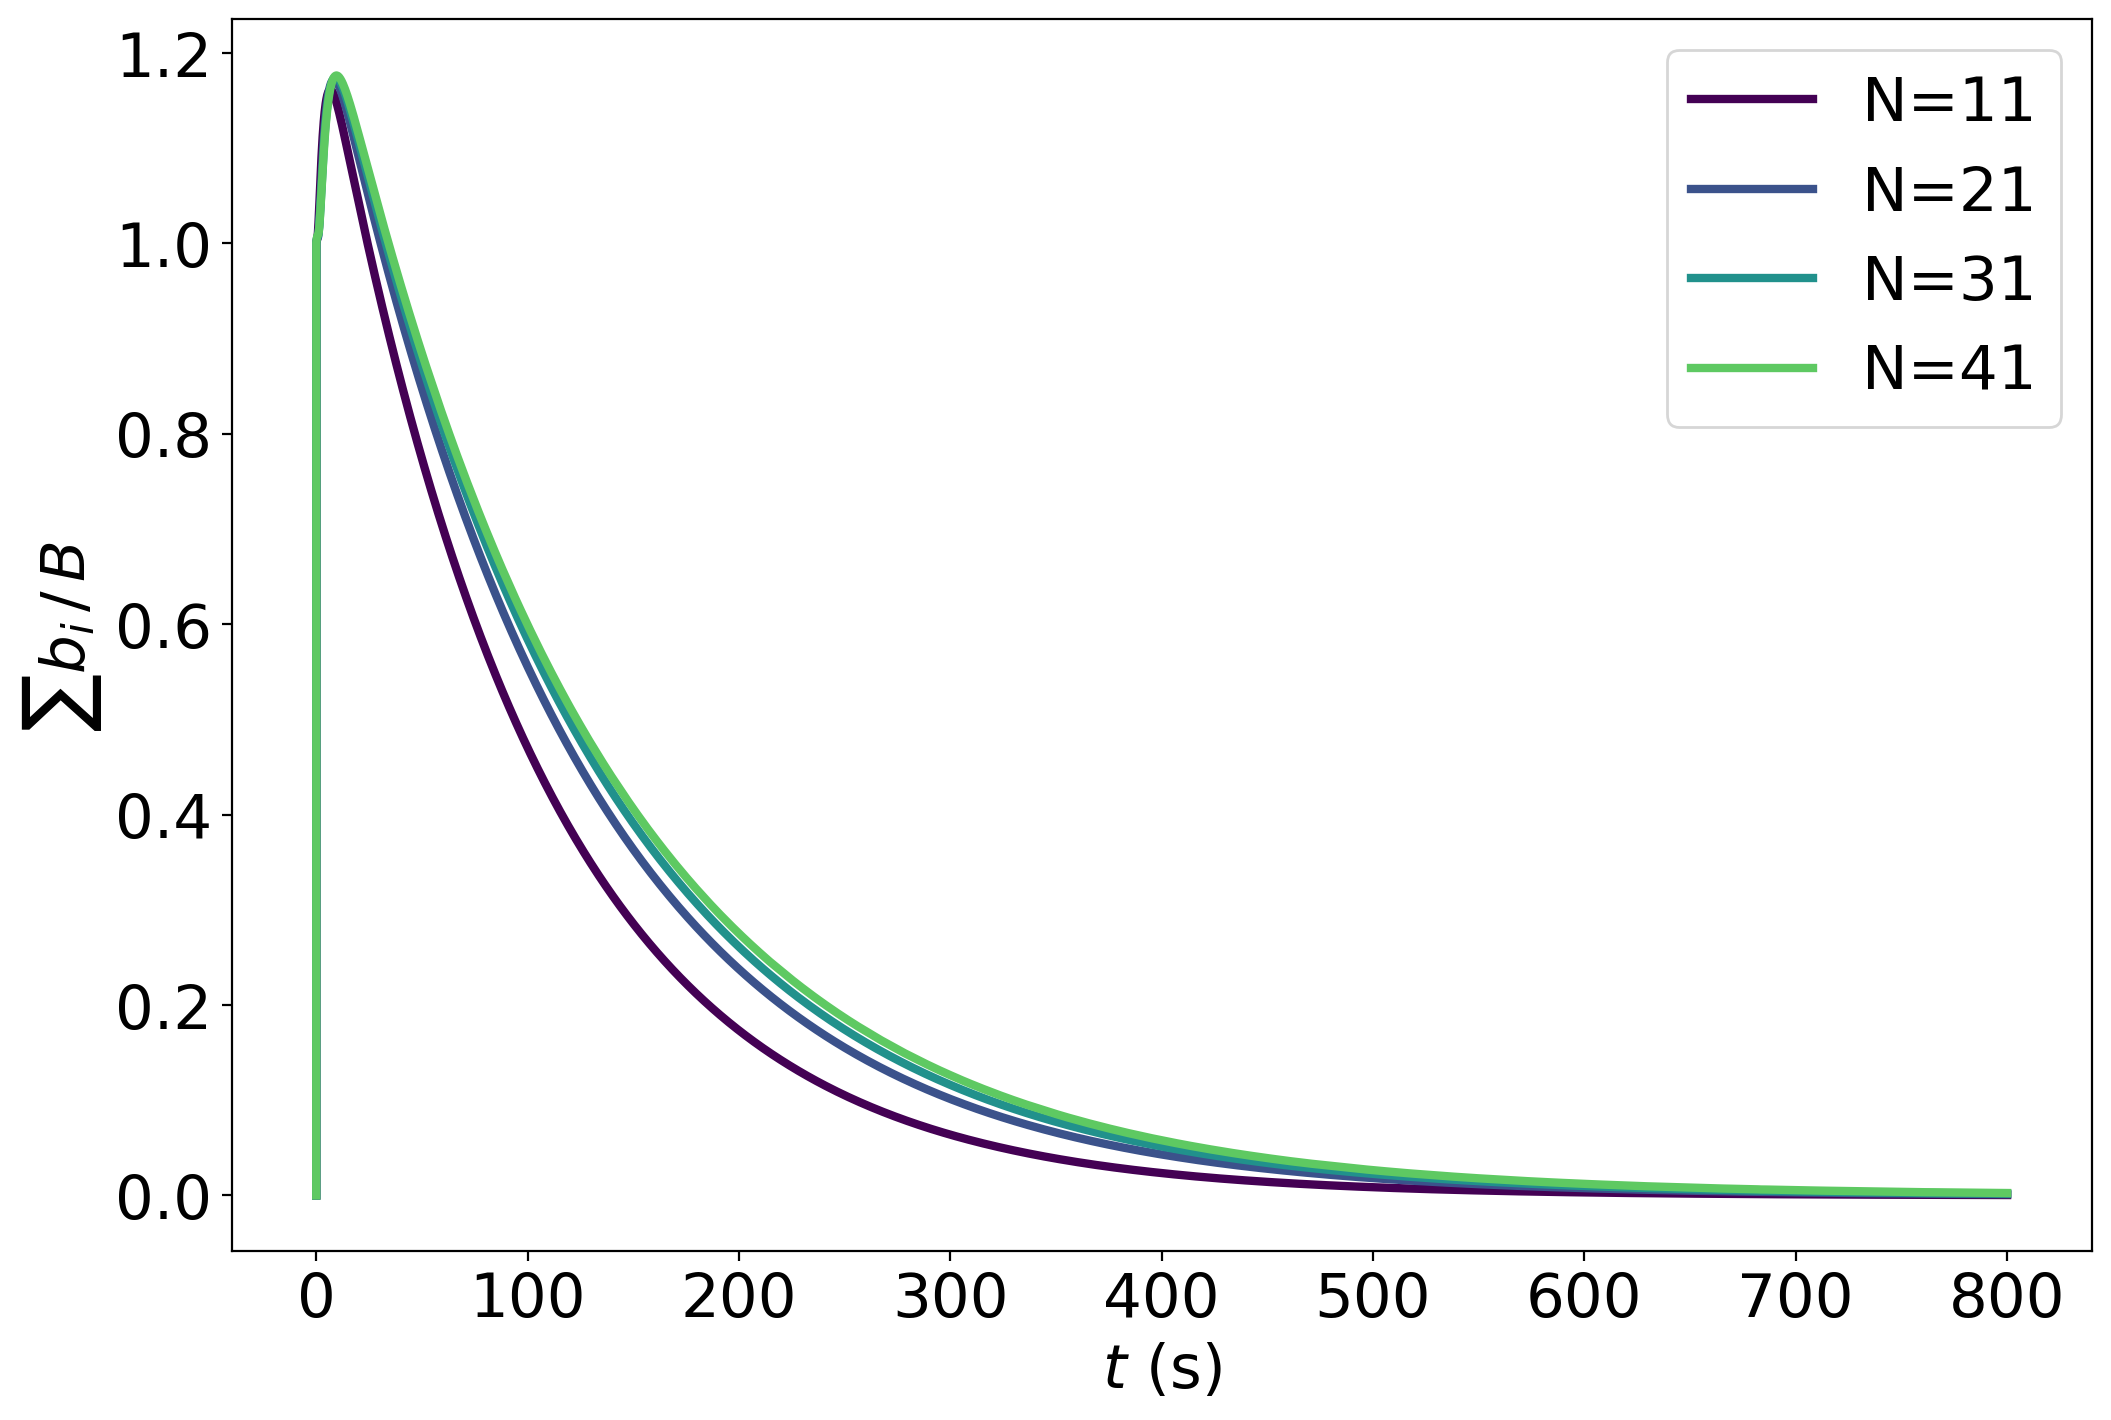

In [3]:
plt.rcParams["font.size"] = 22
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for i in range(Np):
    plt.plot(sim_time[i, :nit[i]]*1.e-6,
             btot[i, :nit[i]],
             marker="none",
             linestyle="-",
             linewidth=3,
             color=plt.cm.viridis(i / max(1, Np)),
             label=f"N={Ngb_list[i]}"
             )
plt.legend()
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\sum b_i \,/ \,B$")
plt.savefig('conv_gbr_ngbn.pdf', dpi=300, format='pdf')
plt.show()